
SWMAL

Assignment 1

Group members: 

Nilas Lorenzen (202307961), Peter Fabiansen (202305295), Rasmus Møller (202305159)



## L6 Training Your Own Linear Regressor

A linear regressor makes a prediction by computing the sum of the input features plus the bias term, in my code this is the intercept term, this is the hypothesis function:
\begin{equation*}
\begin{aligned}
h(\mathbf{x}^{(i)}; \mathbf{w}) &= y_{\text{pred}}^{(i)} \\
&= \mathbf{w}^{\top}\mathbf{x}^{(i)} \quad (\mathbf{x}^{(i)} \text{ with bias element}) \\
&= w_0 \cdot 1 + w_1 x_1^{(i)} + w_2 x_2^{(i)} + \dots + w_d x_d^{(i)}
\end{aligned}
\end{equation*}
Where d is the number of features. To determine the weights w, so that the hypothesis function actually is able predict y-values based on a arbitrary x-value, the weigths are tuned iteratively to minimize the MSE cost function for a Linear Regression model: 
\begin{equation*}
J=\text{MSE}(\mathbf{X}, \mathbf{y_{true};\mathbf{w}}) = \frac{1}{n} \sum_{i=1}^{n} \left(\mathbf{X}\mathbf{w} - \mathbf{y_{true}} \right)^{2} 
\end{equation*}
Which is proportional to the more well known RMSE, and to the loss function J.\\
From the MSE cost function, the closed form solution for the optimal weight can be found:
\begin{equation*}
\mathbf{w}^* = (\mathbf{X}^{\top} \mathbf{X})^{-1} \mathbf{X}^{\top} \mathbf{y}_{\text{true}}
\end{equation*}
But to invert a matrix can be very computationally complex often of order $O(n^3)$, therefore the gradient decent is used instead. The gradient decent finds the minimum of the MSE, by using the partial derivative of the MSE with respect the weights:
\begin{equation*}
\nabla_{\mathbf{w}} J = \left[ \frac{\partial J}{\partial w_1} \quad \frac{\partial J}{\partial w_2} \quad \dots \quad \frac{\partial J}{\partial w_d} \right]^{\top} = \frac{2}{n} \mathbf{X}^{\top} (\mathbf{Xw} - \mathbf{y}_{\text{true}})
\end{equation*}
This is a iteratively process where the next weight is found using:
\begin{equation*}
\mathbf{w}^{(step\, N+1)} = \mathbf{w}^{(step\, N)} - \eta \nabla_{\mathbf{w}} J
\end{equation*}
This can be implemented for the whole training set this is called batch gradient decent, this would be a good approach to find the minimum of the cost function, but can be slow for a large training set. Another method is picking a single random instance this is called stochastic gradient decent, it will be much faster for a large training set, but the cost function will bounce up and down.

In [1]:
import numpy as np

class MyLinReg():
    def __init__(self, eta0=0.03, max_iter=500, tol=1e-3, n_iter_no_change=5, verbose=True):
        self.eta0 = eta0
        self.max_iter = max_iter
        self.tol = tol
        self.n_iter_no_change = n_iter_no_change
        self.verbose = verbose
        self.coef_ = None
        self.intercept_ = None

    def _add_bias(self, X):
        # Prepend a column of 1s to handle the intercept (bias)
        return np.c_[np.ones((X.shape[0], 1)), X]

    def fit(self, X, y, method='batch'):
        """
        Fits the model using either 'batch' or 'sgd' (Stochastic Gradient Descent).
        """
        X_b = self._add_bias(X)
        n_samples, n_features = X_b.shape
        self.coef_ = np.zeros(n_features) # Initialize weights to zero
        
        for epoch in range(self.max_iter):
            if method == 'batch':
                # Batch Gradient Descent: Use all samples at once
                gradients = (2/n_samples) * X_b.T @ (X_b @ self.coef_ - y)
                self.coef_ = self.coef_ - self.eta0 * gradients
            
            elif method == 'sgd':
                # Stochastic Gradient Descent: Update per random sample
                indices = np.random.permutation(n_samples)
                for i in indices:
                    xi = X_b[i:i+1]
                    yi = y[i:i+1]
                    gradients = 2 * xi.T @ (xi @ self.coef_ - yi)
                    self.coef_ = self.coef_ - self.eta0 * gradients
            
            if self.verbose and epoch % 1 == 0:
                print(f"Epoch {epoch}: Loss {self.mse(X, y):.4f}")

    def predict(self, X):
        X_b = self._add_bias(X)
        return X_b @ self.coef_

    def mse(self, X, y_true):
        y_pred = self.predict(X)
        return np.mean((y_pred - y_true)**2)

    def score(self, X, y_true):
        """Calculates the R^2 score."""
        y_pred = self.predict(X)
        ss_res = np.sum((y_true - y_pred)**2)
        ss_tot = np.sum((y_true - np.mean(y_true))**2)
        return 1 - (ss_res / ss_tot)

    def __str__(self):
        return f"MyLinReg(eta0={self.eta0}, max_iter={self.max_iter})"
    
    def LossHistory(self, X, y):
        """Returns the history of the loss during training, used in L7."""
        loss_history = []
        for epoch in range(self.max_iter):
            self.fit(X, y)
            loss_history.append(self.mse(X, y))
        return loss_history


### Qf: Smoke testing

In [ ]:
# Mini smoke test for your linear regressor: TestMyLinReg

import sys
import numpy

### SOME NIFTY HELPER FUNS ###

def isVector(y, expected_n=-1):
    assert isinstance(y, numpy.ndarray), f"expected type 'numpy.array' but got {type(y)}"
    assert y.ndim==1, f"expected y.ndim==1 but got {y.ndim}"
    assert expected_n<0 or expected_n==y.shape[0], f"expected vector of size {expected_n} but got size {y.shape}"
    return True

def isMatrix(X, expected_m=-1, expected_n=-1):
    assert isinstance(X, numpy.ndarray), f"expected type 'numpy.array' but got {type(X)}"
    assert X.ndim==2, f"expected X.ndim==2 but got {X.ndim}"
    assert expected_m<0 or expected_m==X.shape[0], f"expected matrix of size {expected_m}x{expected_n} but got size {X.shape}"
    assert expected_n<0 or expected_n==X.shape[1], f"expected vector of size {expected_m}x{expected_n} but got size {X.shape}"
    return True

def PrintMatrix(x, label="", precision=12, linewidth=60):
    hasFancy = False
    try:
        # NOTE: how does multiple import behave, any performance issues?
        from libitmal.utils import PrintMatrix as FancyPrintMatrix
        hasFancy = True
    except Exception as ex:
        Warn("could not import PrintMatrix from libitmal.utils, defaulting to simple function..")

    if hasFancy:
        FancyPrintMatrix(x, label=label, precision=precision, linewidth=linewidth)
    else:
        # default simple implementation
        print(f"{label}{' ' if len(label)>0 else ''}{x}")

def Col(color):
    hasFancy = False
    try:
        from libitmal.Utils.colors import Col as FancyCol
        hasFancy = True
    except Exception as ex:
        Warn("could not import Col from libitmal.Utils.colors, defaulting to simple function..")

    if hasFancy:
        return FancyCol(color)
    else:
        return ""

def ColEnd():
    hasFancy = False
    try:
        from libitmal.Utils.colors import ColEnd as FancyColEnd
        hasFancy = True
    except Exception as ex:
        Warn("could not import Col from libitmal.Utils.colors, defaulting to simple function..")

    if hasFancy:
        return FancyColEnd()
    else:
        return ""

def PrintOutput(msg, pre_msg, ex=None, color="", filestream=sys.stdout):

    def FormatTxt(txt, linewidth=60, prefix="", replacetabs=True):
        assert isinstance(txt, str)
        assert isinstance(linewidth, int) and linewidth > 0
        assert isinstance(prefix, str)

        if replacetabs:
            txt = txt.replace("\t","    ")

        r = ""
        n = 0
        m = 0
        for i in txt:
            m += 1
            if n >= linewidth:
                if not i.isspace() and m < len(txt) and not txt[m].isspace():
                    r += "\\" # add hypen
                r += "\n" + prefix
                n = 0

            if n == 0 and i.isspace():
                continue # skip leading space

            r += i
            n += 1

            if i == "\n":
                r += prefix
                n = 0

        return r

    col_beg = Col(color)
    col_end = ColEnd()

    prefix = "".ljust(len(pre_msg)) 
    msg = FormatTxt(msg, prefix=prefix)
    
    print(f"{col_beg}{pre_msg}{msg}{col_end}\n", file=filestream)

    if ex is not None:
        #msg += f"\n   EXCEPTION: {ex} ({type(ex)})"
        PrintOutput(str(ex), prefix + "EXCEPTION: ", None, "red", filestream)


def Warn(msg, ex=None):
    PrintOutput(msg, "WARN:  ", ex, "lyellow")


def Err(msg, ex=None):
    PrintOutput(msg, "ERROR: ", ex, "lred" )
    raise Exception(msg) if ex is None else ex


def Info(msg):
    PrintOutput(msg, "INFO:  ", None, "lpurple")


def SimpleAssertInRange(x, expected, eps):
    #assert isinstance(x, numpy.ndarray)
    #assert isinstance(expected, numpy.ndarray)
    #assert x.ndim==1 and expected.ndim==1
    #assert x.shape==expected.shape
    assert eps>0
    assert numpy.allclose(x, expected, eps) # should rtol or atol be set to eps?


def GenerateData():
    X = numpy.array([[8.34044009e-01],[1.44064899e+00],[2.28749635e-04],[6.04665145e-01]])
    y = numpy.array([5.97396028, 7.24897834, 4.86609388, 3.51245674])
    return X, y


def TestMyLinReg():
    X, y = GenerateData()

    try:
        # assume that your regressor class is named 'MyLinReg', please update/change
        regressor = MyLinReg()
    except Exception as ex:
        Err("your regressor has another name, than 'MyLinReg', please change the name in this smoke test", ex)

    try:
        regressor = MyLinReg(max_iter=200)
    except Exception as ex:
        Err("your regressor can not be constructed via the __init_ for parameter 'max_iter'", ex)
    try:
        regressor = MyLinReg(eta0=0.01)
    except Exception as ex:
        Err("your regressor can not be constructed via the __init_ for parameter 'eta0'", ex)
    try:
        regressor = MyLinReg(verbose=False)
    except Exception as ex:
        Warn("your regressor can not be constructed via the __init_ for parameter 'verbose'", ex)
    try:
        regressor = MyLinReg(tol=1e-3)
    except Exception as ex:
        Warn("your regressor can not be constructed via the __init_ for parameter 'tol'", ex)
    try:
        regressor = MyLinReg(n_iter_no_change=1e-3)
    except Exception as ex:
        Warn("your regressor can not be constructed via the __init_ for parameter 'n_iter_no_change'", ex)

    # create regressor with default hyperparameter values
    # to be used for training, prediction and score..
    try:
        regressor = MyLinReg()
    except Exception as ex:
        Err("your regressor can not be constructed via the __init_ with default parameters", ex)

    try:
        regressor.fit(X, y)
    except Exception as ex:
        Err("your regressor can not fit", ex)

    try:
        y_pred = regressor.predict(X)
        Info(f"y_pred = {y_pred}")
    except Exception as ex:
        Err("your regressor can not predict", ex)

    try:
        score  = regressor.score(X, y)
        Info(f"SCORE = {Col('lblue')}{score}{ColEnd()}")
    except Exception as ex:
        Err("your regressor fails in the score call", ex)


    try:
        w    = None # default
        bias = None # default
        try:
            w = regressor.coef_
            bias = regressor.intercept_
        except Exception as ex:
            w = None
            Warn("your regressor has no coef_/intercept_ atrributes, trying Weights() instead..", ex)
        try:
            if w is None:
                w = regressor.Weights() # maybe a Weigths function is avalible on you model?
                try:
                    assert w.ndim == 1,     "can only handle vector like w's for now"
                    assert w.shape[0] >= 2, "expected length of to be at least 2, that is one bias one coefficient"
                    bias = w[0]
                    w = w[1:]
                except Exception as ex:
                    w = None
                    Err("having a hard time concantenating our bias and coefficients, giving up!", ex)
        except Exception as ex:
            w = None
            Err("your regressor also has no Weights() function, giving up!", ex)
        Info(f"bias         = {bias}")
        Info(f"coefficients = {w}")
    except Exception as ex:
        Err("your regressor fails during extraction of bias and weights (but is a COULD)", ex)

    try:
        from libitmal.utils import PrintMatrix
    except Exception as ex:
        PrintMatrix = SimplePrintMatrix # fall-back
        Warn("could not import PrintMatrix from libitmal.utils, defaulting to simple function..")

    try:
        from libitmal.utils import AssertInRange
    except Exception as ex:
        AssertInRange = SimpleAssertInRange # fall-back
        Warn("could not import AssertInRange from libitmal.utils, defaulting to simple function..")

    try:
        if w is not None:
            if bias is not None:
                w = numpy.concatenate(([bias], w)) # re-concat bias an coefficients, may be incorrect for your implementation!
            
            # TEST VECTOR:
            w_expected = numpy.array([4.046879011698, 1.880121487278])
            
            PrintMatrix(w,          label="       w         =")
            PrintMatrix(w_expected, label="       w_expected=")
            print()
            
            eps = 1E-2 # somewhat big epsilon, allowing some slack..
            AssertInRange(w, w_expected, eps)
            Info("Well, good news, your w and the expected w-vector seem to be very close numerically, so the smoke-test has passed!")
            
            return regressor
        else:
            Warn("cannot test due to missing w information")
    except Exception as ex:
        Err("mini-smoketest on your regressor failed", ex)
    
    return None

Warn("This mini smoke-test may produce false-positives and/or\n false-negatives..")
TestMyLinReg()

print("OK")

WARN:  This mini smoke-test may produce false-positives and/or
       false-negatives..

INFO:  y_pred = [5.6148051  6.75926068 4.04168165 5.18204585]

INFO:  SCORE = 0.49499921191364193

INFO:  bias         = None

INFO:  coefficients = [4.04125007 1.88665707]

       w         =[4.04 1.89]
       w_expected=[4.05 1.88]

INFO:  Well, good news, your w and the expected w-vector seem to be
       very close numerically, so the smoke-test has passed!

OK


### Qh Conclusion

It does take some time to fine-tune the regressor with the correct eto0 and max_iter, but the model will converge to the correct weigths when using the slow and steady batch gradient decent model, but the stochastic gradient decent model is not stable, to find a use-case for the SGD an optimization of the model would be to first use the SGD to find an approximate of the weigths and afterwards use the batch model. 

# L7 SWMAL Exercise

## Learning Curves

### The Generalization Error, Over- and Underfitting, Early Stopping, and Optimal Capacity

<img src="https://itundervisning.ase.au.dk/SWMAL/L07-Generalisation/Figs/dl_generalization_error.png" alt="WARNING: could not get image from server." style="height:500px">


### Qa) The Generalization Error

Fig. 5.3 illustrates the fundamental relationship between a model's capacity (its complexity) and its ability to minimize error on both known and unknown data.

X-axis (Capacity): This represents the model's ability to fit a wide variety of functions. Low capacity means a simple model (like a straight line), while high capacity means a complex model.

Y-axis (Error): This represents the difference between the model’s predictions and the true values.

Underfitting Zone: 
Located on the left side of the graph where capacity is low. Here, both training error and generalization error are high. The model is too simple to capture the underlying structure of the data (e.g., trying to fit a curved relationship with a straight line).

Overfitting Zone:
Located on the right side of the graph where capacity is high. While the training error continues to drop, the generalization error begins to rise. The model has started to "memorize" the noise and specific fluctuations in the training set rather than learning the general pattern.

Generalization Gap:
This is the vertical distance between the training error and the generalization error. As capacity increases, this gap consistently widens. A large gap is a primary symptom of overfitting, indicating that the model's success on training data is not translating to real-world performance.

Optimal Capacity:
Marked by the red vertical line, this is the "sweet spot." It occurs at the point where the generalization error is at its absolute minimum. At this level of capacity, the model is complex enough to learn the underlying patterns (minimizing underfitting) but simple enough to ignore the noise (minimizing overfitting).

### Qb Learning Curves

Adding the ability to remember the previous MSE.

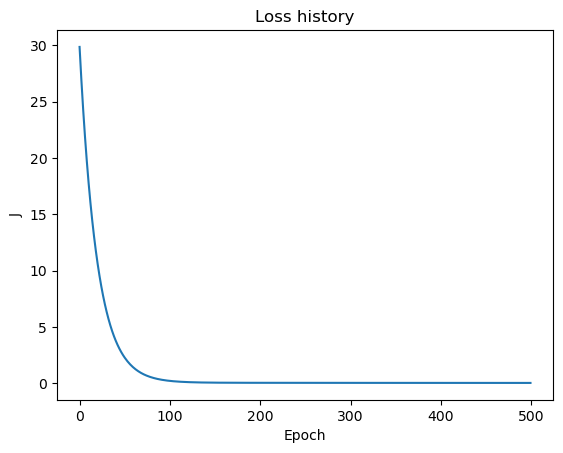

OK


In [ ]:

# Had some problems with importing MyLinReg, so i am just calling it from the bottom of the notebook.

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Create Data
X = np.random.rand(100, 1)
y = 3 * X.squeeze() + 4 + np.random.randn(100) * 0.1

r = MyLinReg(eta0=0.01, max_iter=500) 
r.fit(X, y)

%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plt.plot(r.history_)

ax.set_title("Loss history")
ax.set_xlabel("Epoch")
ax.set_ylabel("J")

zoom_axis = False
if zoom_axis:
    limits_x = ax.get_xlim()
    limits_y = ax.get_ylim()
    ax.set_ylim([0, limits_y[1]/10]) # zoom on y axis
    
plt.show()

print("OK")

### Qc)  Early Stopping

Early stopping is used to prevent overfitting. During training, a model's error on the training set will almost always decrease. However, its error on a separate validation set follows a decreasing curve, it decreases while the model is learning the general patterns, but eventually begins to rise once the model starts "memorizing" the noise or specific details of the training data.

The "Early Stopping" algorithm monitors this validation error and halts training as soon as the error stops improving, for a predefined number of epochs (patience).

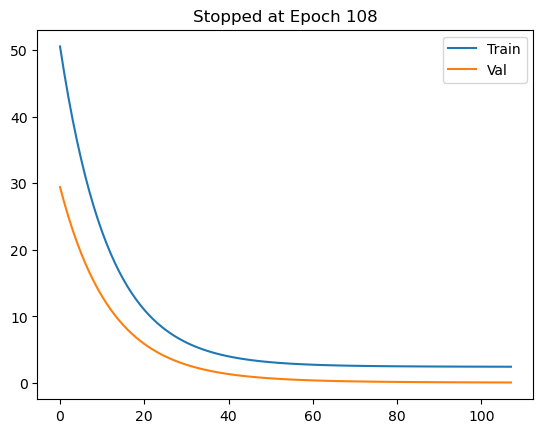

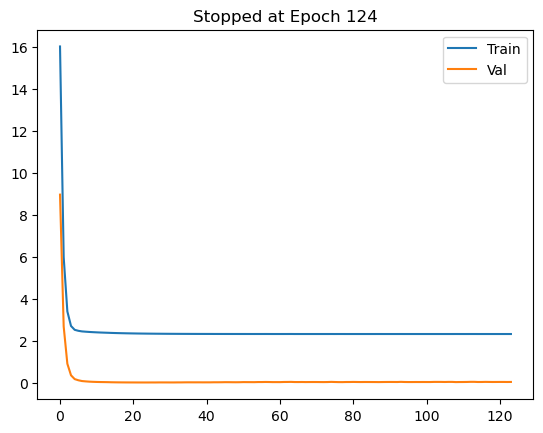

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create Data
X = np.random.rand(100, 1)
y = 3 * X.squeeze() + 4 + np.random.randn(100) * 0.1
X_val = np.random.rand(20, 1)
y_val = 3 * X_val.squeeze() + 4 + np.random.randn(20) * 0.1

# Train Batch (Stops quickly because it's smooth)
model_batch = MyLinReg(max_iter=1000, eta0=0.01, tol=1e-2, n_iter_no_change=5)
model_batch.fit(X_train, y_train, X_val, y_val, method='batch')

# Train SGD
model_sgd = MyLinReg(max_iter=1000, eta0=0.001, tol=1e-6, n_iter_no_change=100) # Increased patience, but higher tol
model_sgd.fit(X_train, y_train, X_val, y_val, method='sgd')

# 3. Plot
plt.plot(model_batch.history_, label='Train')
plt.plot(model_batch.val_history_, label='Val')
plt.title(f"Stopped at Epoch {len(model_batch.history_)}")
plt.legend()
plt.show()


# 3. Plot
plt.plot(model_sgd.history_, label='Train')
plt.plot(model_sgd.val_history_, label='Val')
plt.title(f"Stopped at Epoch {len(model_sgd.history_)}")
plt.legend()
plt.show()

### Qe Conclusion

Observations from the early stopping:
Batch GD is a steady, Because the descent path is smooth, the error decreases consistently. It only stops when the curve is mathematically flat.

SGD has a noisy path. Without high patience, it would stop at the first random "bounce" in error. The high patience (100) allows it to ignore short-term noise and stop only when the long-term trend stops improving.

To really se early stopping in action in action, it would be interesting to fit a polynomial, but that would be a task for another day.

In [ ]:
import numpy as np

class MyLinReg():
    def __init__(self, eta0=0.03, max_iter=500, tol=1, n_iter_no_change=5, verbose=False):
        self.eta0 = eta0
        self.max_iter = max_iter
        self.tol = tol
        self.n_iter_no_change = n_iter_no_change
        self.verbose = verbose
        self.coef_ = None
        self.history_ = []      
        self.val_history_ = []  

    def _add_bias(self, X):
        return np.c_[np.ones((X.shape[0], 1)), X]

    def fit(self, X, y, X_val=None, y_val=None, method='batch'):
        X_b = self._add_bias(X)
        n_samples, n_features = X_b.shape
        self.coef_ = np.zeros(n_features)
        self.best_coef_ = None 
        
        self.history_, self.val_history_ = [], []
        best_val_loss = float('inf')
        no_improvement_count = 0

        for epoch in range(self.max_iter):
            # Optimization
            if method == 'batch':
                gradients = (2/n_samples) * X_b.T @ (X_b @ self.coef_ - y)
                self.coef_ -= self.eta0 * gradients
            elif method == 'sgd':
                indices = np.random.permutation(n_samples)
                for i in indices:
                    xi, yi = X_b[i:i+1], y[i:i+1]
                    gradients = 2 * xi.T @ (xi @ self.coef_ - yi)
                    self.coef_ -= self.eta0 * gradients

            # save history
            train_loss = self.mse(X, y)
            self.history_.append(train_loss)
            
            if X_val is not None:
                val_loss = self.mse(X_val, y_val)
                self.val_history_.append(val_loss)

                # Check for improvement
                if val_loss < best_val_loss - self.tol:
                    best_val_loss = val_loss
                    self.best_coef_ = self.coef_.copy() 
                    no_improvement_count = 0
                else:
                    no_improvement_count += 1

                if no_improvement_count >= self.n_iter_no_change:
                    # Roll back to best weights found
                    self.coef_ = self.best_coef_
                    if self.verbose: print(f"Early stop at {epoch}")
                    break

    def predict(self, X):
        X_b = self._add_bias(X)
        return X_b @ self.coef_

    def mse(self, X, y_true):
        return np.mean((self.predict(X) - y_true)**2)

# L08 - Regulisers

### Qa The Penalty Factor
We have to construct a penalty function that implements $\mathbf{w}^\top \mathbf{w}$, re-using any function from `numpy`.

To solve this problem we merely use numpys dot function as: ```np.dot(w[1:], w[1:])```. This formulation avoids the bias term as is desired.

When the penalty is low, the non-bias weights are small or close to zero. While a high penalty means one or more non-bias weight is large.


In [ ]:
# Qa..first define some numeric helper functions for the test-vectors..

import numpy as np
import collections
from collections.abc import Iterable

def isFloat(x):
    # is there a python single/double float??
    return isinstance(x, float) or isinstance(x, np.float32) or isinstance(x, np.float64)
    # NOT defined on Windows?:   or isinstance(x, np.float128)      

# Checks that a 'float' is 'sane' (original from libitmal)
def CheckFloat(x, checkrange=False, xmin=1E-200, xmax=1E200, verbose=0):
    if verbose>1:
        print(f"CheckFloat({x}, type={type(x)}")
    if isinstance(x, Iterable):
        for i in x:
            CheckFloat(i, checkrange=checkrange, xmin=xmin, xmax=xmax, verbose=verbose)
    else:
        #if (isinstance(x,int)):
        #    print("you gave me an integer, that was ignored")
        #    return
        assert isFloat(x), f"x={x} is not a float/float64/numpy.float32/64/128, but a {type(x)}"
        assert np.isnan(x)==False , "x is NAN"
        assert np.isinf(x)==False , "x is inf"
        assert np.isinf(-x)==False, "x is -inf"
        # NOTE: missing test for denormalized float
        if checkrange:
            z=fabs(x)
            assert z>=xmin, f"abs(x)={z} is smaller that expected min value={xmin}"
            assert z<=xmax, f"abs(x)={z} is larger that expected max value={xmax}"
        if verbose>0:
             print(f"CheckFloat({x}, type={x} => OK")

# Checks that two 'floats' are 'close' (original from libitmal)
def CheckInRange(x, expected, eps=1E-9, autoconverttofloat=True, verbose=0):
    assert eps>=0, "eps is less than zero"
    if autoconverttofloat and (not isFloat(x) or not isFloat(expected) or not isFloat(eps)):
        if verbose>1:
            print(f"notice: autoconverting x={x} to float..")
        return CheckInRange(1.0*x, 1.0*expected, 1.0*eps, False, verbose)
    CheckFloat(x)
    CheckFloat(expected)
    CheckFloat(eps)
    x0 = expected - eps
    x1 = expected + eps
    ok = x>=x0 and x<=x1
    absdiff = np.fabs(x-expected)
    if verbose > 0:
        print(f"CheckInRange(x={x}, expected={expected}, eps={eps}: x in [{x0}; {x1}] => {ok}")
    assert ok, f"x={x} is not within the range [{x0}; {x1}] for eps={eps}, got eps={absdiff}"

print("OK(setup..)")

OK(setup..)


In [ ]:
# TODO: Qa - Penalty factor
    
def Omega(w):
    return np.dot(w[1:], w[1:])
 
# weight vector format: [w_0 w_1 .. w_d], ie. elem. 0 is the 'bias'    
w_a = np.array([1., 2., -3.])  
w_b = np.array([1E10, -3E10])
w_c = np.array([0.1, 0.2, -0.3, 0])

p_a = Omega(w_a)
p_b = Omega(w_b)
p_c = Omega(w_c)

print(f"P(w0)={p_a}")
print(f"P(w1)={p_b}")
print(f"P(w2)={p_c}")

# TEST VECTORS
e0 = 2*2+(-3)*(-3)
e1 = 9e+20
e2 = 0.13

CheckInRange(p_a, e0)
CheckInRange(p_b, e1)
CheckInRange(p_c, e2)

print("OK")

P(w0)=13.0
P(w1)=9e+20
P(w2)=0.13
OK


### Qb Explain the Ridge Plot
Explain what the different $\alpha$ does to the fitting for the `Ridge` model in the plot.

For the Ridge model the the $\alpha$ parameter controls the strenght of the penalty. When $\alpha$ increases the model is therefore punished more for having large weights. This generally makes the curve more smooth and less flexible.

This can also be seen from the resulting plots from the code below. 

When $\alpha=0$, the blue curve, we have no penalty and the fit is thus very wavy and reacts greatly to noise.

When $\alpha=10^{-5}$, the green curve, we have a very small penalty. This results in reduced oscillation and a more smooth curve compared to the blue curve but it is still generally somewhat wavy.

When $\alpha=1$, the red curve, we have much larger penalty making the curve much smoother and flatter compared to the blue and green curves. The curve no longer tries to track every point, which reduces the overfitting but can also results in underfitting if it is too large.


C:\Users\nilas\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.744e+00, tolerance: 9.295e-04
  model = cd_fast.enet_coordinate_descent(
C:\Users\nilas\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.774e+00, tolerance: 9.295e-04
  model = cd_fast.enet_coordinate_descent(


OK(plot)


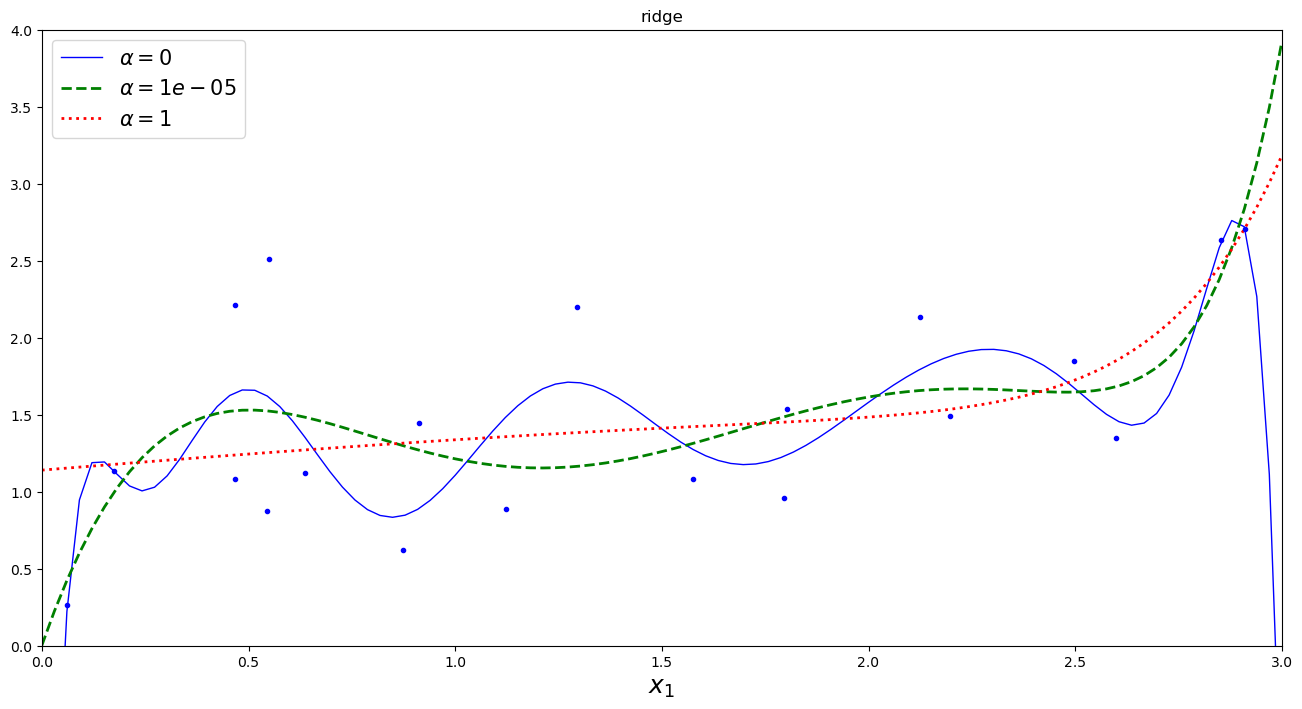

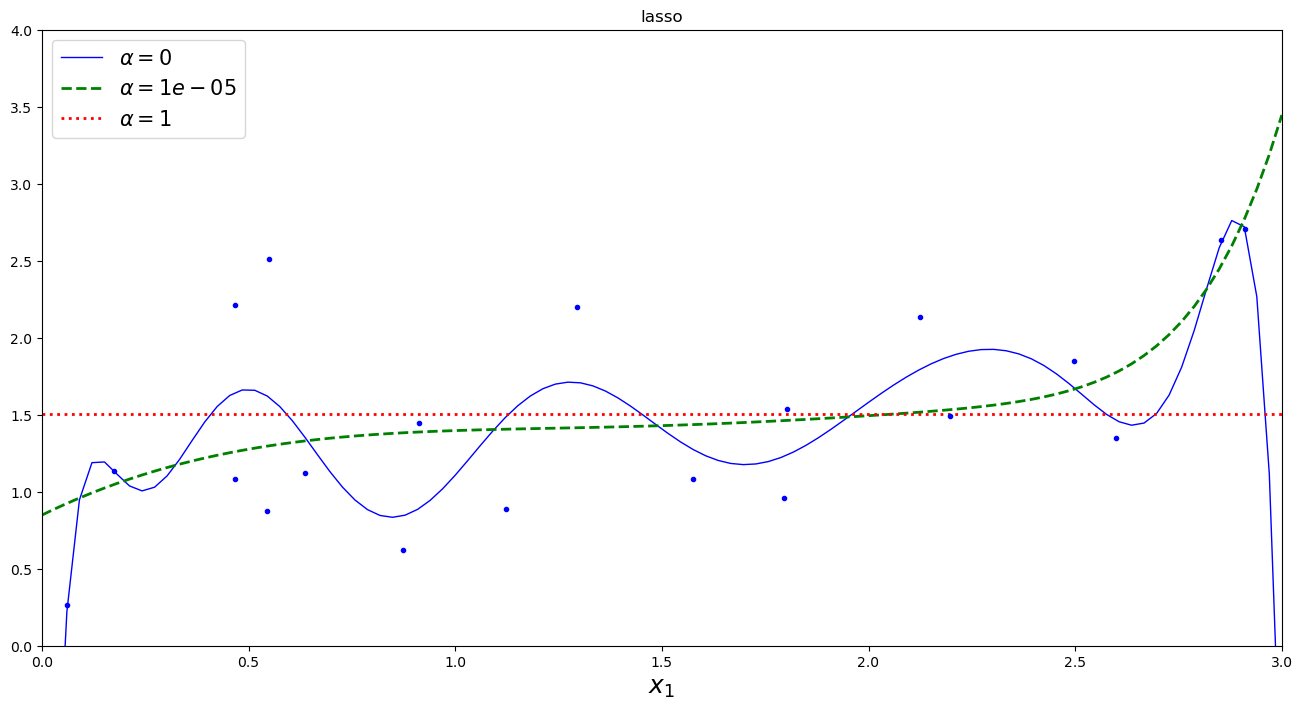

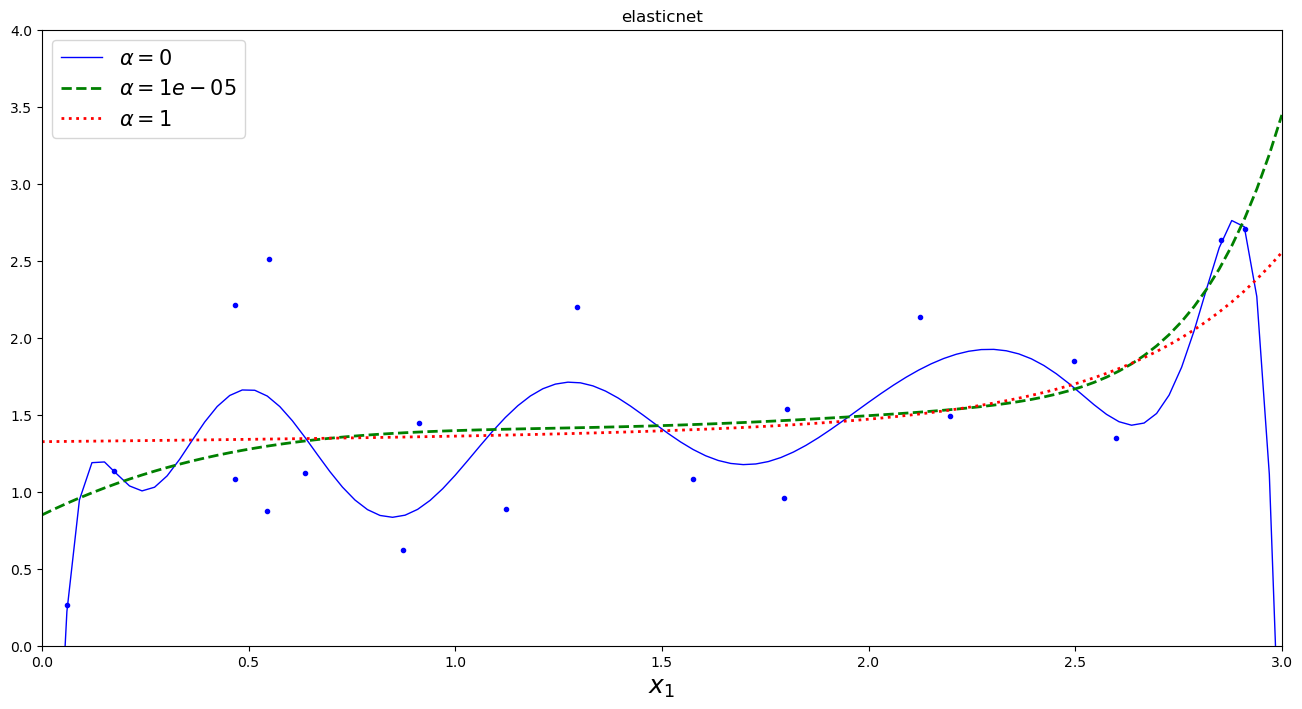

In [ ]:
# TODO: Qb, just run the code..

%matplotlib inline

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, ElasticNet, Lasso

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def FitAndPlotModel(name, model_class, X, X_new, y, **model_kargs):
    plt.figure(figsize=(16,8))
    
    alphas=(0, 10**-5, 1) 
    random_state=42
    
    for alpha, style in zip(alphas, ("b-", "g--", "r:")):
        #print(model_kargs)
        model = model_class(alpha, **model_kargs) if alpha > 0 else LinearRegression()
        model_pipe = Pipeline([
                ("poly_features", PolynomialFeatures(degree=12, include_bias=False)),
                ("std_scaler", StandardScaler()),
                ("regul_reg", model),
            ])
            
        model_pipe.fit(X, y)
        y_new_regul = model_pipe.predict(X_new)
        
        lw = 2 if alpha > 0 else 1
        plt.plot(X_new, y_new_regul, style, linewidth=lw, label=r"$\alpha = {}$".format(alpha))
    
    plt.plot(X, y, "b.", linewidth=3)
    plt.legend(loc="upper left", fontsize=15)
    plt.xlabel("$x_1$", fontsize=18)
    plt.title(name)
    plt.axis([0, 3, 0, 4])

def GenerateData():
    np.random.seed(42)
    m = 20
    X = 3 * np.random.rand(m, 1)
    y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
    X_new = np.linspace(0, 3, 100).reshape(100, 1)
    return X, X_new, y
    
X, X_new, y = GenerateData()

FitAndPlotModel('ridge',      Ridge,        X, X_new, y)
FitAndPlotModel('lasso',      Lasso,        X, X_new, y)
FitAndPlotModel('elasticnet', ElasticNet,   X, X_new, y, l1_ratio=0.1)

print("OK(plot)")

### Qc Explain the Ridge, Lasso and ElasticNet Regularization Methods
We have to explain the different regularization methods for the `Ridge`, `Lasso` and `ElasticNet` models based on the math formulas and figure 4-19 below.

The Ridge model is a regularized version of the linear least square model with L2-norm regularization. The math formulation is defined as:

$J=\|y - Xw\|_2^2 + \alpha\|w\|_2^2$

Or the closed formed solution

$\hat{w} = \left(X^T X + \alpha A\right)^{-1} X^T y$

Where $\alpha$, as previously mentiond, is a parameter controlling the regularization strength.

In relation to figure 4-19, shown below, because Ridge uses a L2 penalty based on the squared size of the coefficients, the constraint region seen on the figure is round. When the Ridge then shrinks the coefficients towards zero, this smooth boundary results in an optimum where the coefficents are small but not quite zero.

The Lasso model, or Least Absolute Shrinkage and Selection Operator Regression, is a linear model with the L1-norm regularization. The Lasso model of scikit-learn optimizes:

$J=\frac{1}{2\,n_{\text{samples}}}\|y - Xw\|_2^2 + \alpha \|w\|_1$

Looking at figure 4-19, because Lasso uses L1 penalty the constraint region seen has corners which means it often reaches a point where some of the weights actually becomes zero, as it the case on the figure. This means it can often help produce simpler models by completely excluding some features.

The ElastisNet model combines L1 and L2 regularization and can thereby be considered a combination of Ridge and Lasso regularization. The model optimizes:

$J=\frac{1}{2n_{\text{samples}}}\,\lVert y - Xw \rVert_2^2
+ \alpha \cdot \mathrm{l1\_ratio} \cdot \lVert w \rVert_1
+ 0.5 \cdot \alpha \cdot (1 - \mathrm{l1\_ratio}) \cdot \lVert w \rVert_2^2$

Where $l1\_ratio$ is the ratio of L1 regularization to L2 regularization such that the degree of reguliarzation of each method can be controlled.

In relation to the figure, ElasticNet is a balance of the Ridge and Lasso models and therefore reaches a balance between feature selection and shrinkage.

<img src="https://itundervisning.ase.au.dk/SWMAL/L08-Regularisation/Figs/Screenshot_HOML_fig_4-19b.png" alt="WARNING: could not get image from server.">


# L09/dataanalyse

## Qa Beskrivelse af datasæt til O4 projekt
For the O4 project we have chosen to investigate the reliabilty of flexible and wearable antennas. With the rise of wearable technoligies like smartwatches there is a massive demand for reliable hardware cabable of suriving a bit of sweat or a knock. Our goal will be to develop a machine learning model able to predict imminent fault cases and be a part of the maintenance and detection system. The machine learning model should be a classifier able to ascertain whether or not the wifi and or bluetooth is failing and also classify which kind of fault is present. To train our model we have chosen [This data set from kaggle.com](https://www.kaggle.com/datasets/amineipad/antenna-performance-and-fault-detection-dataset?fbclid=IwY2xjawQffuJleHRuA2FlbQIxMQBzcnRjBmFwcF9pZAEwAAEeJ2UxEK4SsTF78Us3f-ALRqmDz68CFkv2aszLsnn0NTB3mq0-Kfri-Ghet-M_aem_khEFRjyx4IXRwn4GQIPcEw), it should work well due to its comprehensive feature list and a sample size just over 1100. The features include Length, Width, Height, Permittivity, Conductivity, and epsilon_r. Alongside these physical traits, the dataset captures critical radio frequency (RF) performance indicators like Return Loss (S11), Voltage Standing Wave Ratio (VSWR), Gain, Efficiency, and Bandwidth. From the description of the dataset: "Crucially, the dataset features explicit classifications for various environmental and physical fault conditions—such as Humidity/Sweat, Bending, Cracks, and Rupture/Coupure—and tracks their impact on the operational status of both WiFi and BT functionalities. It is an excellent resource for predictive maintenance, anomaly detection, and robust wearable antenna design using machine learning." Furthermore we as a group hope this project will enable us to obtain a deeper understanding of antenna perfomance and the parameters related to this. The data in this set was "collected through a series of controlled simulations and empirical measurements that emulate real-world conditions for wearable antennas. Various physical deformations and environmental stressors were applied to the antenna models, including bending at different radii, introducing structural cracks or ruptures, and simulating changes in dielectric properties due to humidity or sweat." So we should have in mind that the data probably represents cleaner versions of the faults and is limited to these kinds of fault, not entirely covering the real world in which the wearable antennas would exist.
We intend to apply this dataset to perform Supervised Learning, as we are provided with the correct target labels (the operational status) for each antenna instance. Specifically, we will frame this problem as a Classification task. We will train an algorithm to predict the operational status, treating it as a binary classification problem (e.g., 1 for operational, 0 for defective) given the physical and electrical features. If time permits, we may expand this into a multiclass classification problem where we predict the specific failure mode. 
Given that some of the features have quite high values we will very likely have to use a pipeline and scale the data, depending of course on the type of model we ultimately choose to employ.

   Length  Width  Height  Permittivity  Conductivity  Bend   Feed    S11  \
0   46.72  38.62    1.46          1.51      12210.65  0.56 -10.27  -7.09   
1   40.32  36.17    1.30          1.61       9589.73  0.48 -17.33  -7.92   
2   43.84  35.89    1.17          1.53       4067.44  0.99 -11.95 -18.97   
3   43.77  39.46    1.26          1.88      13052.58  0.67 -10.07 -12.89   
4   46.48  39.66    1.30          2.44      12682.11  1.08 -17.57 -22.94   

   VSWR  Gain  Efficiency  Bandwidth       WiFi Fault        BT Fault  \
0  3.41  5.09       62.26     102.74           Cracks          Cracks   
1  2.47  5.17       66.61      96.06  Rupture_Coupure        No_Fault   
2  3.20  5.07       83.42     150.03          Bending  Strong_Flexion   
3  1.72  3.83       42.22      54.23      Body_Effect         Coupure   
4  1.44  3.48       77.39      93.00   Strong_Flexion        No_Fault   

  WiFi Status BT Status  epsilon_r  
0       Fault     Fault       3.90  
1       Fault    Normal       

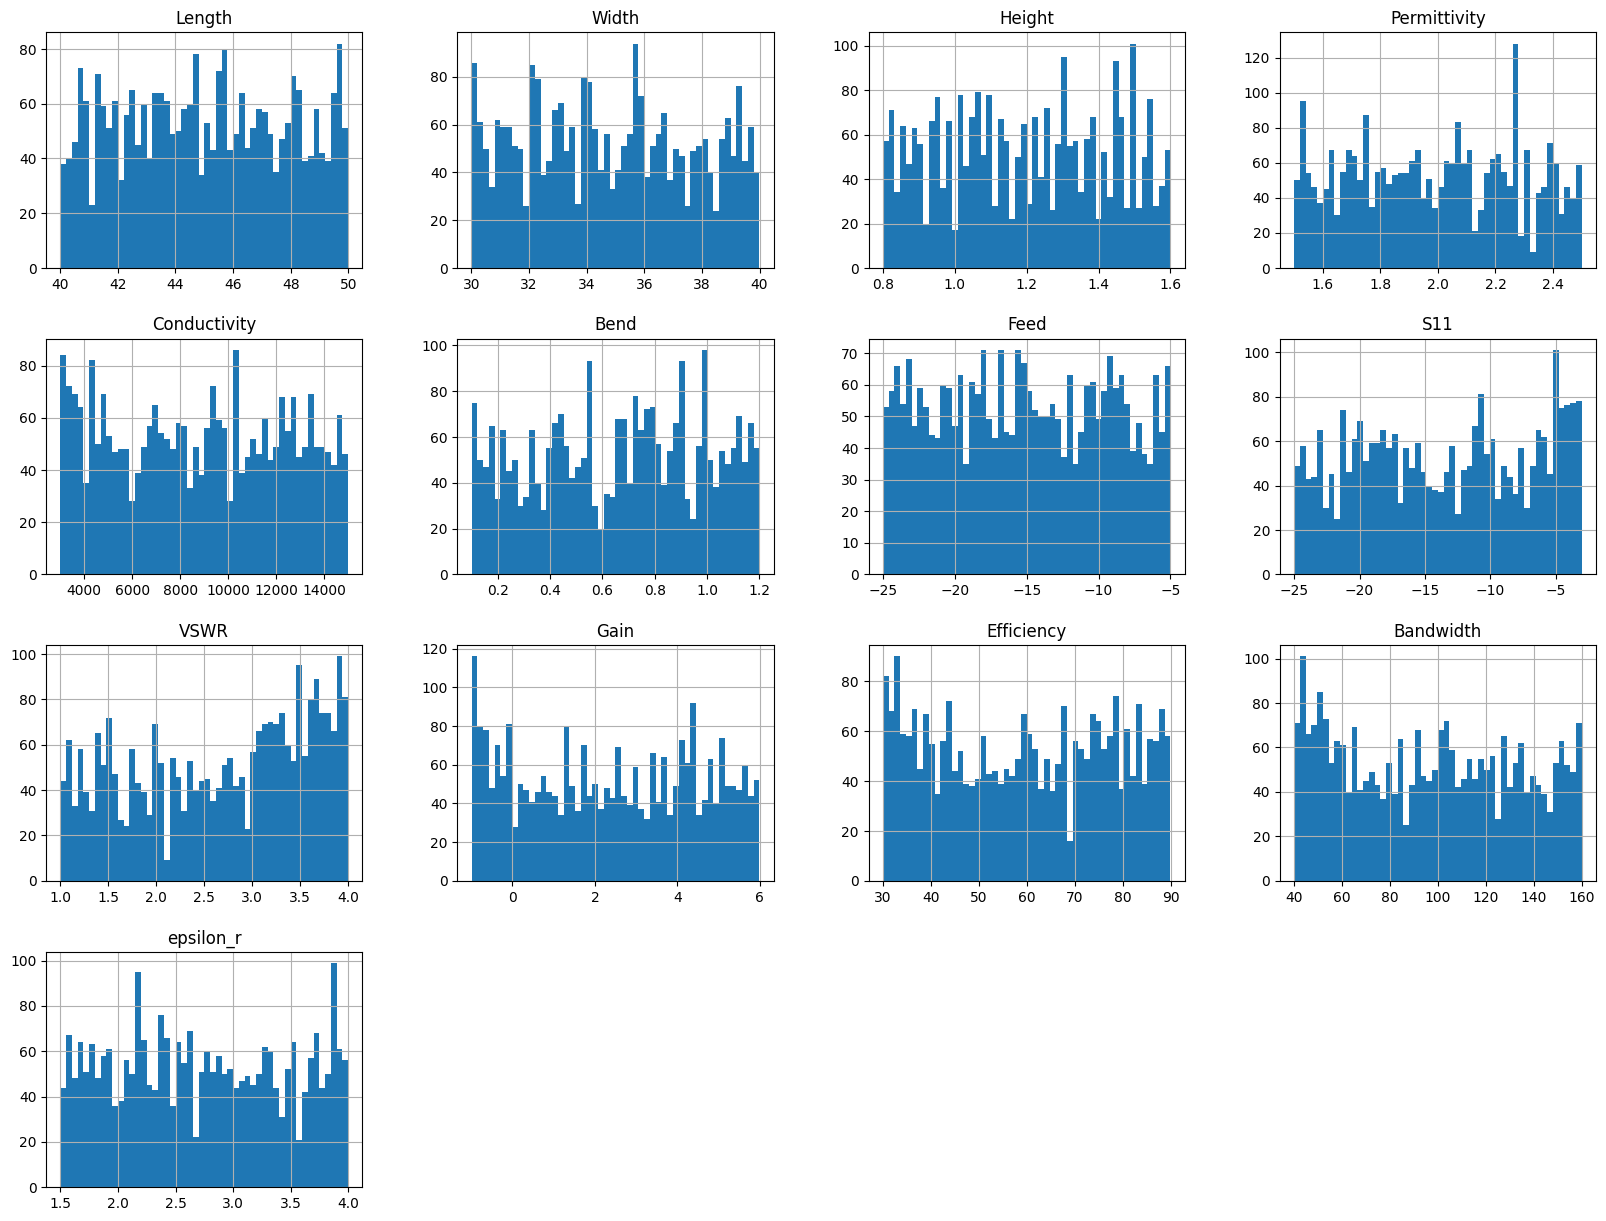

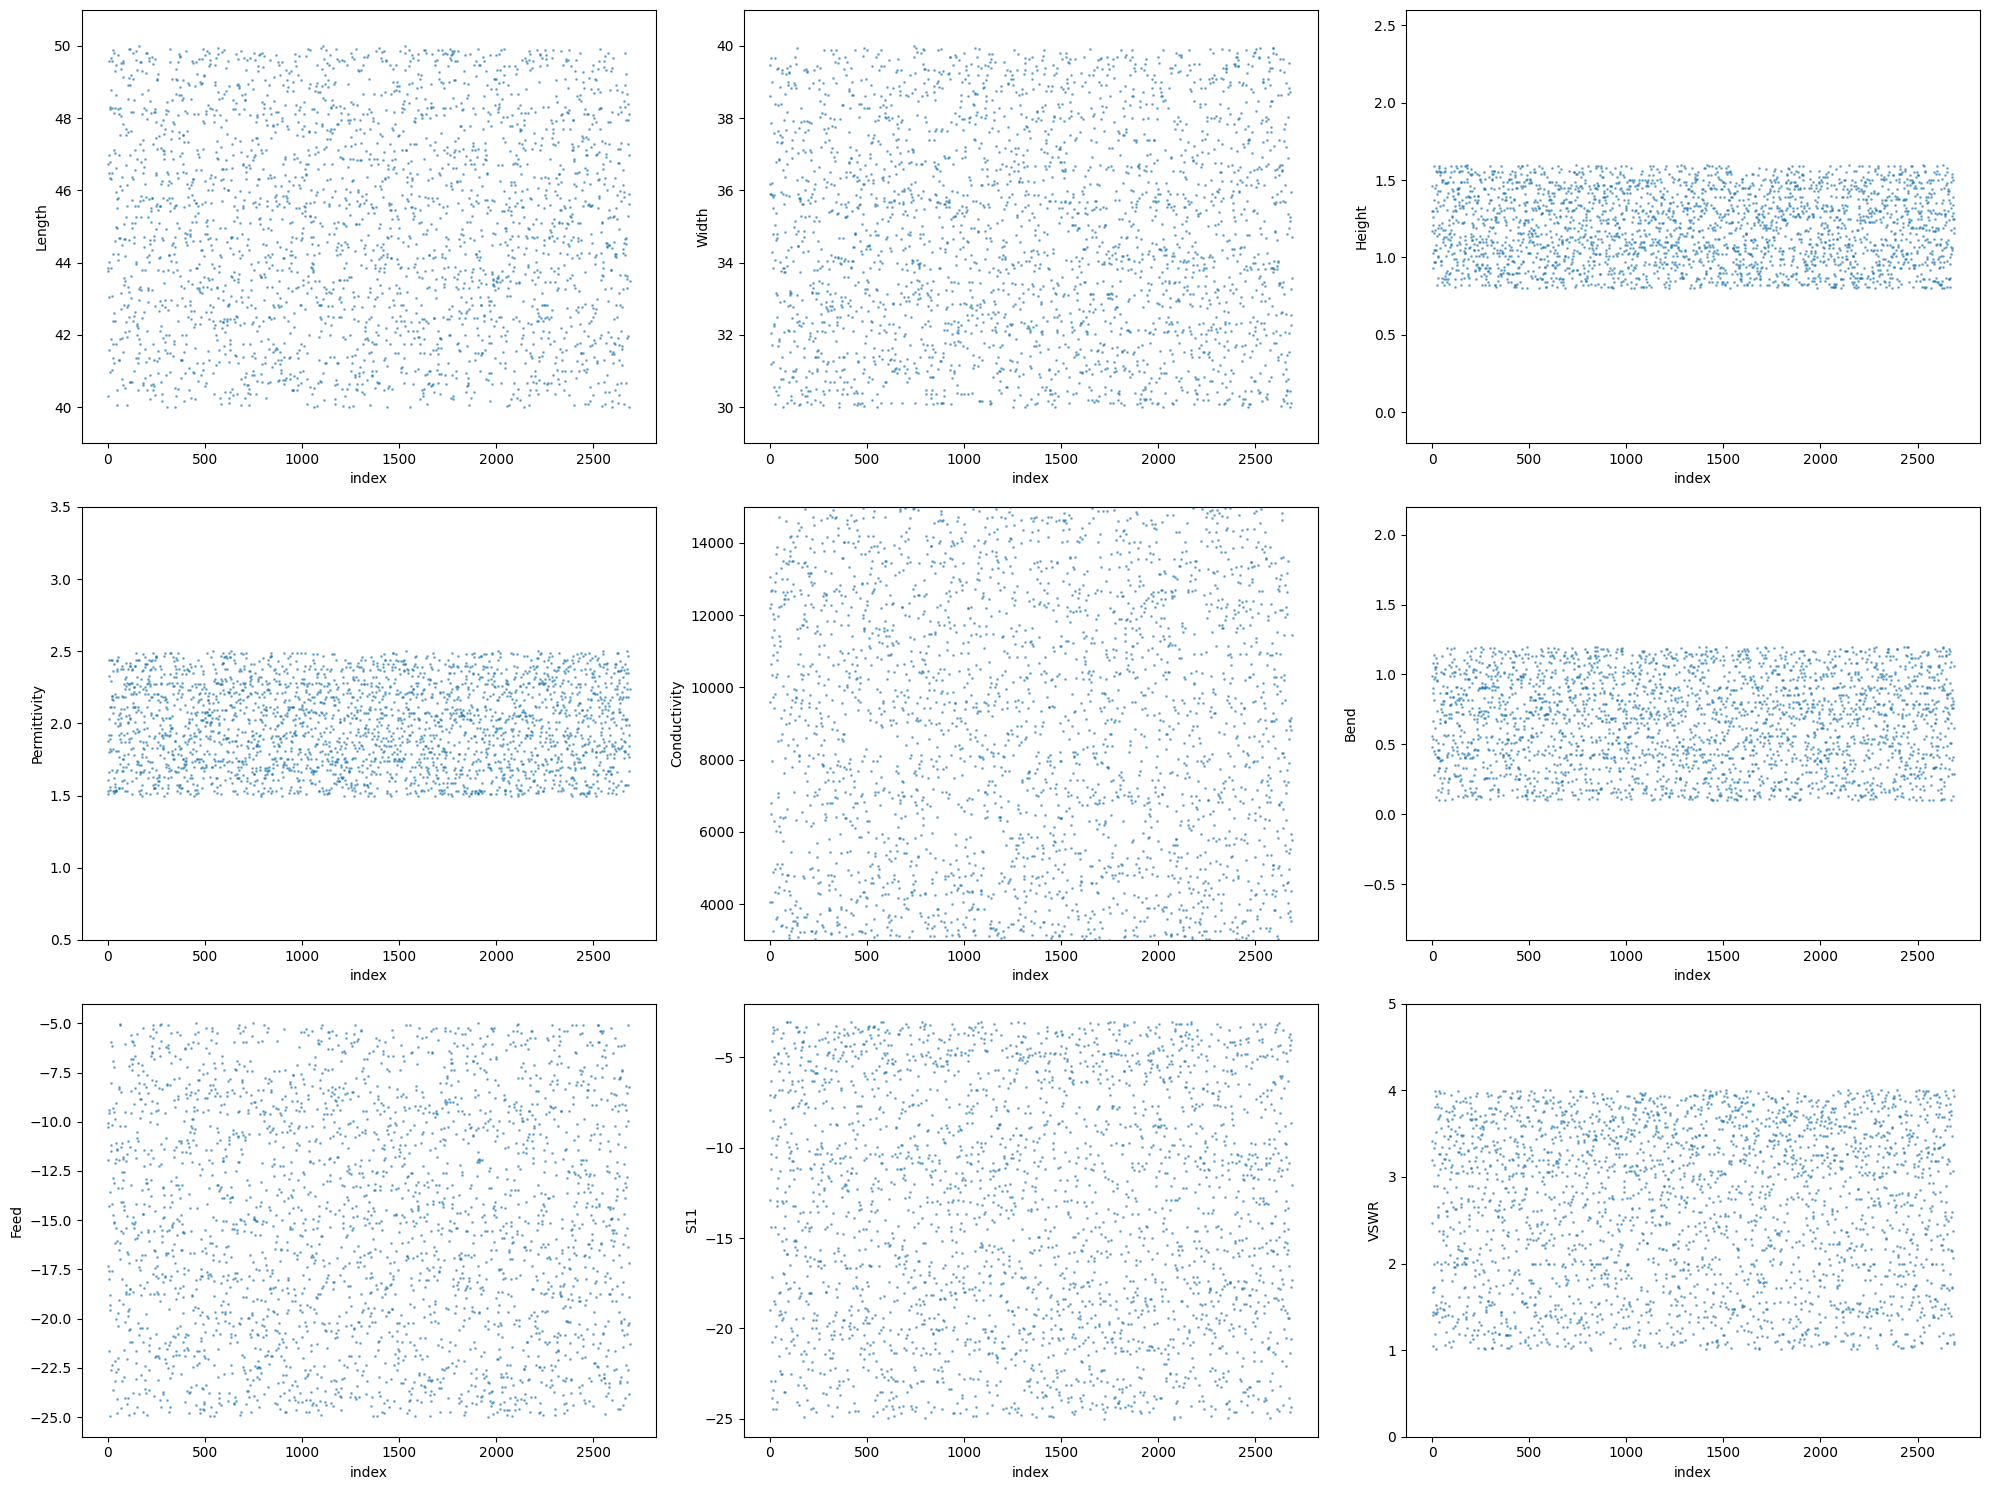

From the plots we see that there does not seem to be singular outliers to be concerned about, there is however for some features 
a quite large relative deviation from minimun values to maximum 
Furthermore we see that the controlled enviroment has resulted in pretty firm limits of the data. We see on the histograms 
that the data is clearly not normal, which is a good sign for the real life mimicing.


In [ ]:
# Importing the data
import pandas as pd
import os

Bat_dat = "antenna_fault.csv"

# Load the data into a DataFrame
df = pd.read_csv(Bat_dat)

print(df.head()) #Prints the first five rows to get an idea of how the dataset looks
print(df.info()) #Prints some infomation about the data and their type (String/float)
print(df.describe()) #Prints count, mean, standar deviation, and the quatiles for each feature

import matplotlib.pyplot as plt

df.hist(bins=50, figsize=(20,15))
plt.show()

df_plot = df.reset_index()

#Scatterplotting the data to look for outliers
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))
axes = axes.flatten()

numeric_cols = df.select_dtypes(include=['number']).columns

for i, col in enumerate(numeric_cols[:9]):
    df_plot.plot(kind='scatter', x='index', y=col, ax=axes[i], s=1, alpha=0.5)
    axes[i].set_ylim(df[col].min() -1, (df[col].max()) + 1)

plt.tight_layout()
plt.show()

print("From the plots we see that there does not seem to be singular outliers to be concerned about, there is however for some features " \
"\na quite large relative deviation from minimun values to maximum " \
"\nFurthermore we see that the controlled enviroment has resulted in pretty firm limits of the data. We see on the histograms " \
"\nthat the data is clearly not normal, which is a good sign for the real life mimicing.")

# L10 Pipelines
Code given:

In [ ]:
%matplotlib inline

import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def LoadDataFromL01():
    filename = "Data/itmal_l01_data.pkl"
    with open(f"{filename}", "rb") as f:
        (X, y) = pickle.load(f)
        return X, y

X, y = LoadDataFromL01()

print(f"X.shape={X.shape},  y.shape={y.shape}")

assert X.shape[0] == y.shape[0]
assert X.ndim == 2
assert y.ndim == 1  # did a y.ravel() before saving to picke file
assert X.shape[0] == 29

# re-create plot data (not stored in the Pickel file)
m = np.linspace(0, 60000, 1000)
M = np.empty([m.shape[0], 1])
M[:, 0] = m

print("OK")

X.shape=(29, 1),  y.shape=(29,)
OK


C:\Users\bruger\AppData\Local\Temp\ipykernel_14948\3445365470.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  (X, y) = pickle.load(f)


The MLP may mis-fit the data, seen in the, sometimes, bad R^2 score..

lin.reg.score(X, y)=0.73
    MLP.score(X, y)=-135663.72

OK


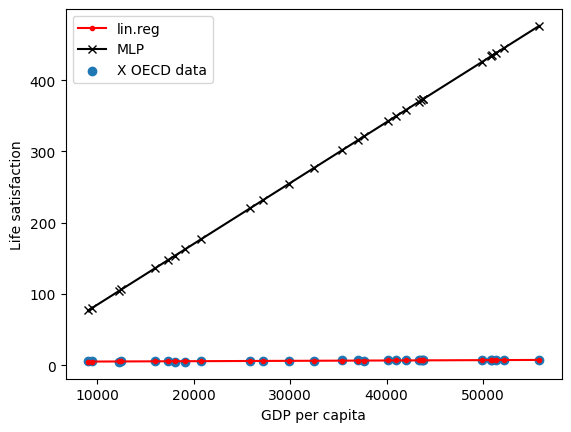

In [ ]:
def isNumpyData(t: np.ndarray, expected_ndim: int):
    assert isinstance(expected_ndim, int), f"input parameter 'expected_ndim' is not an integer but a '{type(expected_ndim)}'"
    assert expected_ndim>=0, f"expected input parameter 'expected_ndim' to be >=0, got {expected_ndim}"
    if t is None:
        print("input parameter 't' is None", file=sys.stderr)
        return False
    if not isinstance(t, np.ndarray):
        print("excepted numpy.ndarray got type '{type(t)}'", file=sys.stderr)
        return False
    if not t.ndim==expected_ndim:
        print("expected ndim={expected_ndim} but found {t.ndim}", file=sys.stderr)
        return False
    return True

def PlotModels(model1, model2, X: np.ndarray, y: np.ndarray, name_model1: str, name_model2: str):
    
    # NOTE: local function is such a nifty feature of Python!
    def CalcPredAndScore(model, X: np.ndarray, y: np.ndarray,):
        assert isNumpyData(X, 2) and isNumpyData(y, 1) and X.shape[0]==y.shape[0]
        y_pred_model = model.predict(X)
        score_model = r2_score(y, y_pred_model) # call r2
        return y_pred_model, score_model    

    assert isinstance(name_model1, str) and isinstance(name_model2, str)

    y_pred_model1, score_model1 = CalcPredAndScore(model1, X, y)
    y_pred_model2, score_model2 = CalcPredAndScore(model2, X, y)

    plt.plot(X, y_pred_model1, "r.-")
    plt.plot(X, y_pred_model2, "kx-")
    plt.scatter(X, y)
    plt.xlabel("GDP per capita")
    plt.ylabel("Life satisfaction")
    plt.legend([name_model1, name_model2, "X OECD data"])

    l = max(len(name_model1), len(name_model2))
    
    print(f"{(name_model1).rjust(l)}.score(X, y)={score_model1:0.2f}")
    print(f"{(name_model2).rjust(l)}.score(X, y)={score_model2:0.2f}")

# lets make a linear and MLP regressor and redo the plots
mlp = MLPRegressor(hidden_layer_sizes=(10, ),
                   solver='adam',
                   activation='relu',
                   tol=1E-5,
                   max_iter=100000,
                   verbose=False)
linreg = LinearRegression()

mlp.fit(X, y)
linreg.fit(X, y)

print("The MLP may mis-fit the data, seen in the, sometimes, bad R^2 score..\n")
PlotModels(linreg, mlp, X, y, "lin.reg", "MLP")
print("\nOK")

### Qa Create a Min/max scaler for the MLP
The MLP usually expects values in the |1| range and so we should "normalize" the data with a scaler which is what is done here below:

In [ ]:
norm_X = np.linalg.norm(X)

# Divide to get the unit vector
X_scaled = X/norm_X
assert (X_scaled <= 1).all()
# Setup MLPRegressor
mlp_scaled = MLPRegressor( hidden_layer_sizes=(10,), solver='adam', activation='relu', tol=1E-5, max_iter=100000, verbose=False)
mlp_scaled.fit(X_scaled, y)
scaled_score = mlp_scaled.score(X_scaled,y)
print("R2 = ",scaled_score)
print("Clearly much better this time around\nOK")

# We are asked to manually scale X to be between 0 and 1 which i have done but the header says a min maxer so that is implemented below
X_scaled = (X - min(X))/(max(X)-min(X))
assert (X_scaled <= 1).all()
# Setup MLPRegressor
mlp_scaled = MLPRegressor( hidden_layer_sizes=(10,), solver='adam', activation='relu', tol=1E-5, max_iter=100000, verbose=False)
mlp_scaled.fit(X_scaled, y)
scaled_score = mlp_scaled.score(X_scaled,y)
print("R2 = ",scaled_score)
print("About the same as the unit approach\nOK")

R2 =  0.7179732182539813
Clearly much better this time around
OK
R2 =  0.7254365933623266
About the same as the unit approach
OK


### Qb Scikit-learn Pipelines


In [ ]:
# Initialize the scaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
assert (X_scaled <= 1).all()
minMaxMLP = MLPRegressor( hidden_layer_sizes=(10,), solver='adam', activation='relu', tol=1E-5, max_iter=100000, verbose=False)

minMaxMLP.fit(X_scaled, y)
minMax_score = minMaxMLP.score(X_scaled,y)
print("R2 = ",minMax_score)
print("Not a clear difference in the score between the two scaled versions, although the MinMax seems somewhat faster than the linear algebra approach\nOK")

R2 =  0.7264268967207181
Not a clear difference in the score between the two scaled versions, although the MinMax seems somewhat faster than the linear algebra approach
OK


lin.reg.score(X, y)=0.73
    MLP.score(X, y)=0.77
Very clean looking and it works!
OK


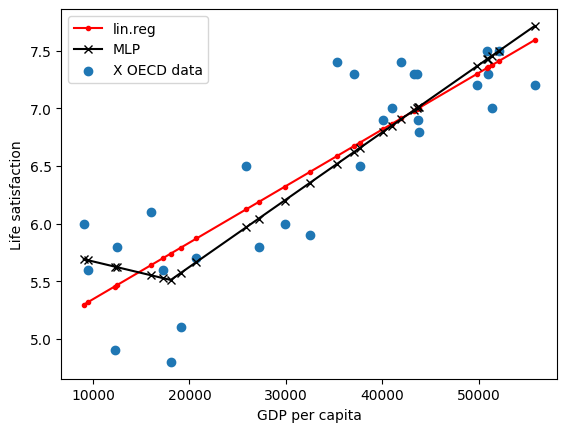

In [ ]:
# Now for the pipelining
from sklearn.pipeline import Pipeline
pipeMLP = Pipeline([
    ('scaler', MinMaxScaler()),
    ('mlp', MLPRegressor(hidden_layer_sizes=(10,), solver='lbfgs', max_iter=10000))
])

pipeMLP.fit(X,y)
pipeMLP.score(X,y)
PlotModels(linreg, pipeMLP, X, y, "lin.reg", "MLP")
print("Very clean looking and it works!\nOK")


# Qc
### Outliers and the Min-max Scaler vs. the Standard Scaler
Since the min-max scaler works by using the formula $x_{scaled} = \frac{x-min(X)}{max(X)-min(X)}$, which clearly shows that a MinMax scaler can be heavily skewed by a single outlier, either to values relatively to high or low. If max(X) is far greater than the next biggest value in X this will misrepresent the data once scaled. A standaes scaler instead functions by $x_{scaled} = \frac{x-x_{mean}}{x_{standardDeviation}}$, which is an approach that is more robust and in a greater sense takes the whole dataset into consideration.

### Qd Modify the MLP Hyperparameters

In [ ]:
print("n, current_score")
for n in range(2, 11):
    # 1. Initialize model with n neurons in 1 hidden layer
    mlp = MLPRegressor(hidden_layer_sizes=(n,), solver='lbfgs', max_iter=10000)
    
    # 2. Fit the model
    mlp.fit(X_scaled, y)
    
    # 3. Calculate the score
    current_score = mlp.score(X_scaled, y)
    
    # 4. Print results
    print(n, current_score)
print("We see that for n>2 the mlp most of the time returns usable scores, when run a couple of times n values up to 7 produces negative scores though")

n, current_score
2 0.7344414353058631
3 0.7344414349850926
4 0.7344414354352837
5 0.7344414211643752
6 0.7344414350263119
7 0.812285230475843
8 0.7344414105711117
9 0.734441350134227
10 0.7673228023865772
We see that for n>2 the mlp most of the time returns usable scores, when run a couple of times n values up to 7 produces negative scores though


In [ ]:
# MLP only uses early stop for sgd or ADAMS method, ADAMS is default
MLPADAM = MLPRegressor(hidden_layer_sizes=(10,), max_iter=10000)
MLPADAM.fit(X_scaled, y)
EarlyStopScore = MLPADAM.score(X_scaled, y)
print(EarlyStopScore)

print("n, current_score")
for n in range(1, 11):
    MLPEarly = MLPRegressor(hidden_layer_sizes=(n,), max_iter=10000, early_stopping= True)
    MLPEarly.fit(X_scaled, y)
    EarlyStopScoren = MLPEarly.score(X_scaled, y)
    print(n,   EarlyStopScoren)
print("it is hard to descipher how much the early stopping interferes but it is clear that the ADAM solver is not well suited for this dataset\nIt is generally better for large datasets where the lbfgs is better for smaller sets like the one used here")

0.5306495511592128
n, current_score
1 -0.013946950765975075
2 0.42203023202282675
3 -2.6236251579641334
4 0.09930837670813564
5 0.6810248234864043
6 0.03795647081000042
7 0.34341941965975
8 0.7312125371603321
9 -0.4626648315803832
10 0.6473818017141123
it is hard to descipher how much the early stopping interferes but it is clear that the ADAM solver is not well suited for this dataset
It is generally better for large datasets where the lbfgs is better for smaller sets like the one used here


In [ ]:
mlplog = MLPRegressor(hidden_layer_sizes=(10,), max_iter=10000, activation= 'logistic')
mlplog.fit(X_scaled,y)
Logscore = mlplog.score(X_scaled,y)
print("The score using logarithmic activation function is", Logscore, ", significantly further from 1 than the lbfgs but seems about the same as the default activation with the ADAm solver")

mlptanh = MLPRegressor(hidden_layer_sizes=(10,), max_iter=10000, activation= 'tanh')
mlptanh.fit(X_scaled,y)
Tanhscore = mlptanh.score(X_scaled,y)
print("The score using Tanh activation function is", Tanhscore, ", some where in the middle of the other 2")


The score using logarithmic activation function is 0.4264357339386422 , significantly further from 1 than the lbfgs but seems about the same as the default activation with the ADAm solver
The score using Tanh activation function is 0.6740105944924493 , some where in the middle of the other 2


### Qf Conclusion
We have seem many facets of the MLP regressor, how much it improves when it recieves values in the range it expects. How it can be streamlined using the pipelines. Not only does the pipeline approach save time and space, but it also ensures one does not forget to scale new data whenever it is added. We have realized that while the min max scaler seems good and intuitive it is vulnarable to extreme outliers and might cause problems that can be hard to pin down once one has moved further along in the data handling process. We also saw that for this relatively small dataset the lbfgs solver is both faster and better than the ADAM default solver approach. The impact of the activation choices were a bit harder to descipher especially with the nature of changing scores produces by the MLP model. To further investigate the strengths of each choice one could introduce a randomstate hyperparameter and run for shared but random values of this. That seems a bit excessive at this point however so that will remain a thought. 

# L12 - MLP with Keras


In [ ]:

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from time import strftime


## 1. Load Dataset (Fashion-MNIST)

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()


In [ ]:
# Split training data into training and vvalidation sets - skiped since we are using validation_split

#X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
#y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

# Normalize pixel values to range [0, 1]
X_test = X_test / 255.0
X_train = X_train_full / 255.0
y_train = y_train_full

## 2. Visualize sample images

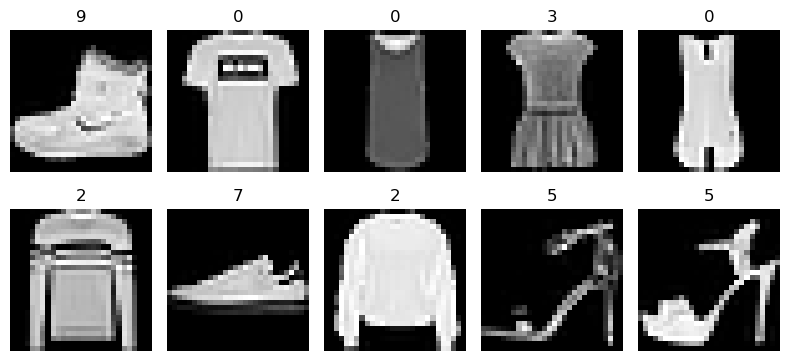

In [ ]:
plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")
    plt.tight_layout()
plt.show()

### Task on dataset:
- T2.a) Replace the numeric labels with class names
The numeric labels are replaced with class names merely using the already defined indices as shown below.

In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

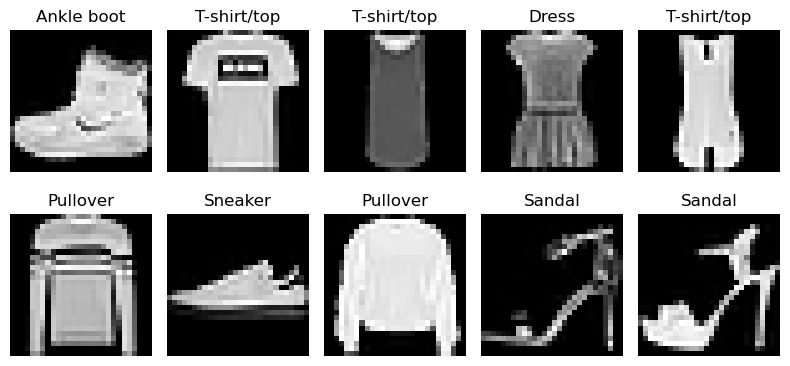

In [ ]:
# T2.a: Replace with Class names
plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[int(y_train[i])])  # <- map 0-9 to name
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Build a basic MLP Model

In [ ]:

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])


## 4. Compile Model (Try SGD vs Adam)

In [ ]:

model.compile(
    #optimizer='adam',  # TODO: try 'adam'
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_44 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Callbacks

In [ ]:

log_dir = "logs/mlp_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]


## 6. Train Model

In [ ]:

history = model.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7143 - loss: 0.9049 - val_accuracy: 0.7965 - val_loss: 0.6201
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8102 - loss: 0.5692 - val_accuracy: 0.8134 - val_loss: 0.5368
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8262 - loss: 0.5051 - val_accuracy: 0.8347 - val_loss: 0.4880
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8366 - loss: 0.4728 - val_accuracy: 0.8378 - val_loss: 0.4662
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8438 - loss: 0.4495 - val_accuracy: 0.8426 - val_loss: 0.4507
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8491 - loss: 0.4337 - val_accuracy: 0.8488 - val_loss: 0.4333
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8534 - loss: 0.4201 - val_accuracy: 0.8532 - val_loss: 0.4230
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8570 - loss: 0.4101 - val_accuracy: 0.

## 7. Plot Learning Curves

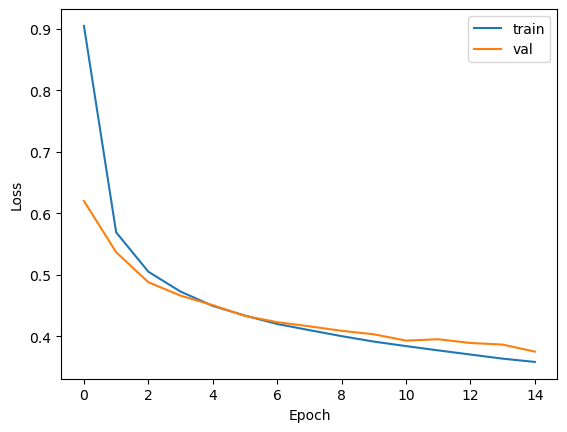

In [ ]:

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


## 8. Tasks and questions on the MLP model

### T8.a) Plot accuracy curves as well

The accuracy curve is plotted based on the already stored data for accuracy in history.


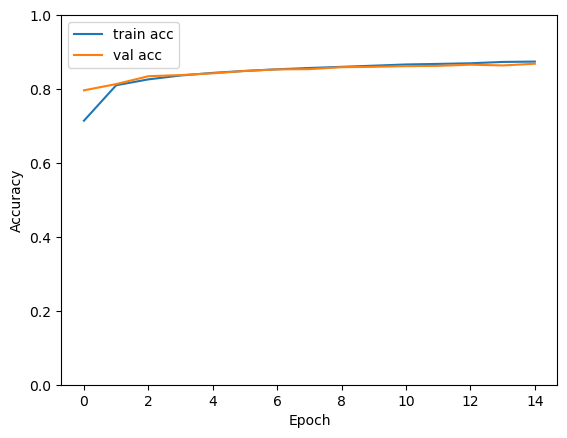

In [ ]:
# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.show()

### T8.b) Analyze TensorBoard logs

Opening the Tensorboard provides the following epoc-accuracy plot 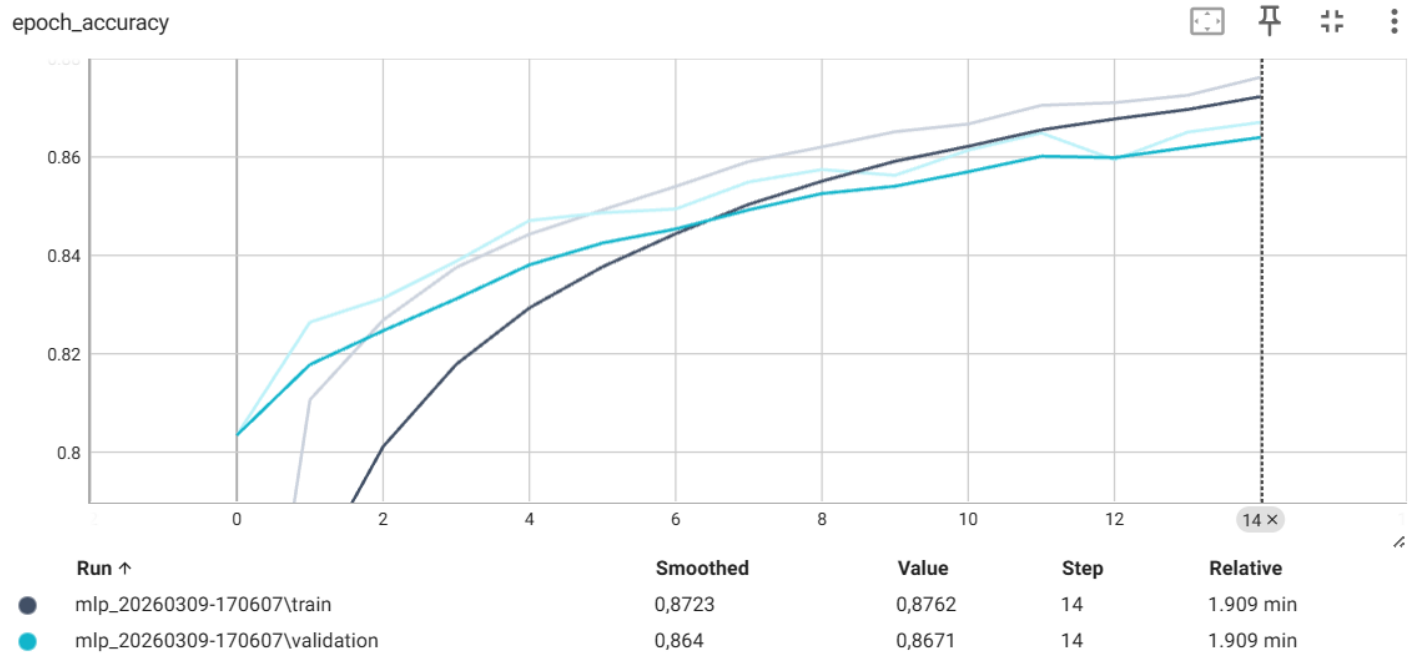 From which it can be seen that the model learns steadily and that the validation closely tracks the training of the alogrithm as is desired. There is also no strong signs of overfitting and the performance can in general be considered decent. Adjusting the smoothness results in a similar result except for there being more spikes, especially in the validation results, in the curves, along with the overall end position being closer together for higher smoothness, the above plot is from 0.6 smoothness.

We furthmore test what happens when the learning rate is changed to 0.001 and the optimizer is changed to Adam.

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4975 - loss: 1.7369 - val_accuracy: 0.6471 - val_loss: 1.3361
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6598 - loss: 1.1556 - val_accuracy: 0.6862 - val_loss: 1.0060
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6956 - loss: 0.9395 - val_accuracy: 0.7147 - val_loss: 0.8676
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7233 - loss: 0.8363 - val_accuracy: 0.7420 - val_loss: 0.7905
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7456 - loss: 0.7730 - val_accuracy: 0.7598 - val_loss: 0.7396
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7617 - loss: 0.7282 - val_accuracy: 0.7702 - val_loss: 0.7019
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7751 - loss: 0.6931 - val_accuracy: 0.7808 - val_loss: 0.6706
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7851 - loss: 0.6644 - val_accuracy: 0.

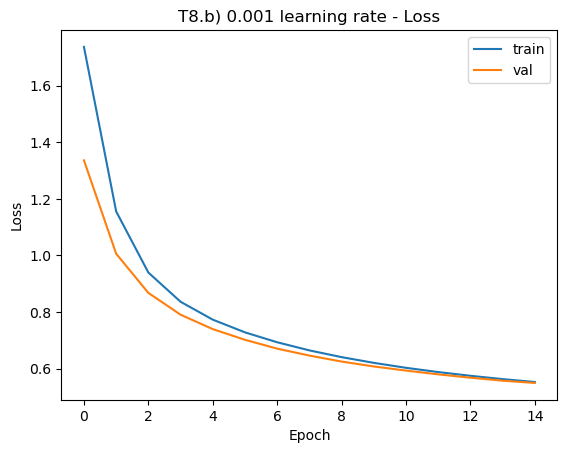

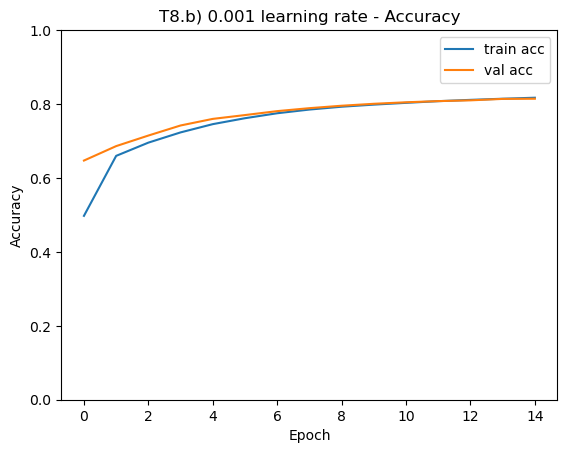

In [ ]:
## T8. b - Learning rate of 0.001
model_small = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

#The learning rate is changed here
model_small.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = "logs/mlp_0.001_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

history_small = model_small.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)
plt.plot(history_small.history['loss'], label='train')
plt.plot(history_small.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('T8.b) 0.001 learning rate - Loss')
plt.show()

plt.figure()
plt.plot(history_small.history['accuracy'], label='train acc')
plt.plot(history_small.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.title('T8.b) 0.001 learning rate - Accuracy')
plt.show()

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4220 - loss: 1.8895 - val_accuracy: 0.6438 - val_loss: 1.4757
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6613 - loss: 1.2551 - val_accuracy: 0.6945 - val_loss: 1.0638
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7023 - loss: 0.9794 - val_accuracy: 0.7268 - val_loss: 0.8861
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7340 - loss: 0.8507 - val_accuracy: 0.7497 - val_loss: 0.7934
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7558 - loss: 0.7754 - val_accuracy: 0.7686 - val_loss: 0.7342
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7711 - loss: 0.7232 - val_accuracy: 0.7824 - val_loss: 0.6915
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7829 - loss: 0.6843 - val_accuracy: 0.7865 - val_loss: 0.6596
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7900 - loss: 0.6540 - val_accuracy: 0.

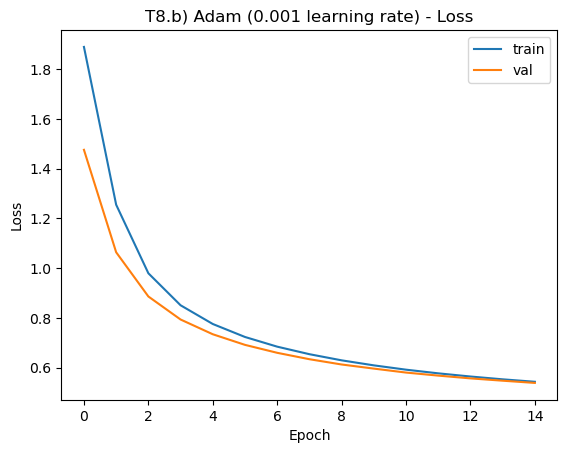

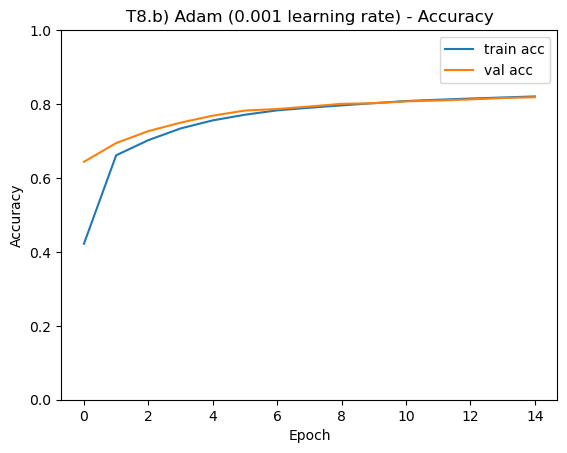

In [ ]:
## T8. b - Adam
model_adam = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

#The learning rate is changed here
model_adam.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = "logs/mlp_adam_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

history_adam = model_adam.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)
plt.plot(history_adam.history['loss'], label='train')
plt.plot(history_adam.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('T8.b) Adam (0.001 learning rate) - Loss')
plt.show()

plt.figure()
plt.plot(history_adam.history['accuracy'], label='train acc')
plt.plot(history_adam.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.title('T8.b) Adam (0.001 learning rate) - Accuracy')
plt.show()

## Additional tasks on the MLP model to optimize model accuracy
### T8.c) Experiment with more training epochs.

To see what more training epocs does, it is increased from 15 to 70, see code below. We note that early stopping occurred at 55.



Epoch 1/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7149 - loss: 0.9086 - val_accuracy: 0.7876 - val_loss: 0.6234
Epoch 2/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8064 - loss: 0.5736 - val_accuracy: 0.8150 - val_loss: 0.5359
Epoch 3/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8257 - loss: 0.5077 - val_accuracy: 0.8274 - val_loss: 0.4859
Epoch 4/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8358 - loss: 0.4752 - val_accuracy: 0.8336 - val_loss: 0.4726
Epoch 5/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8432 - loss: 0.4539 - val_accuracy: 0.8405 - val_loss: 0.4640
Epoch 6/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8481 - loss: 0.4372 - val_accuracy: 0.8479 - val_loss: 0.4323
Epoch 7/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8525 - loss: 0.4243 - val_accuracy: 0.8476 - val_loss: 0.4323
Epoch 8/70
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8574 - loss: 0.4116 - val_accuracy: 0.

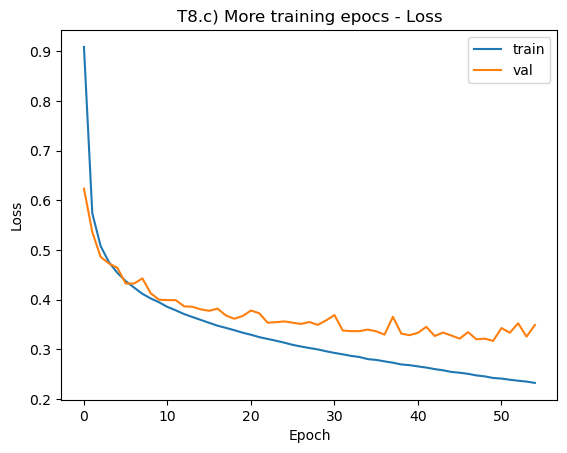

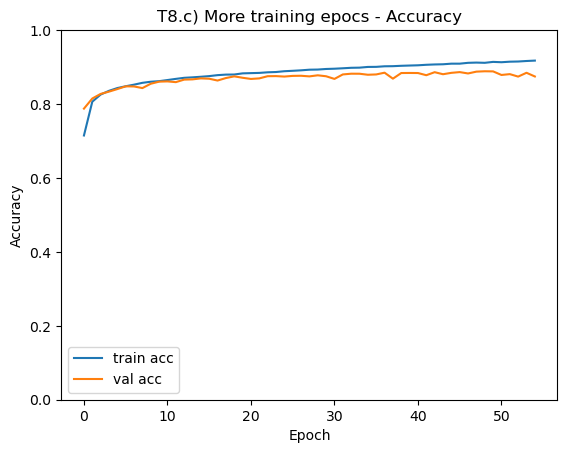

In [ ]:
## T8. c - More training epochs
model2 = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model2.compile(
    #optimizer='adam',  # TODO: try 'adam'
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = "logs/mlp_70_epochs_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]
# Increases epochs from 15 to 30
history2 = model2.fit(
    X_train, y_train,
    epochs=70,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)
plt.plot(history2.history['loss'], label='train')
plt.plot(history2.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('T8.c) More training epocs - Loss')
plt.show()

plt.figure()
plt.plot(history2.history['accuracy'], label='train acc')
plt.plot(history2.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.title('T8.c) More training epocs - Accuracy')
plt.show()

### T8.d) Add a third hidden layer and train the model

We add another hidden layer of 64 neurons. The epochs is set back to 15.

From the results it can be seen that the accuracy is slighly higher and the loss a bit lower but it is not a large improvement in this case.

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6990 - loss: 0.9306 - val_accuracy: 0.7919 - val_loss: 0.6159
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8086 - loss: 0.5617 - val_accuracy: 0.8162 - val_loss: 0.5159
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8266 - loss: 0.4956 - val_accuracy: 0.8276 - val_loss: 0.4805
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8390 - loss: 0.4606 - val_accuracy: 0.8448 - val_loss: 0.4445
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8479 - loss: 0.4370 - val_accuracy: 0.8491 - val_loss: 0.4308
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8535 - loss: 0.4173 - val_accuracy: 0.8497 - val_loss: 0.4376
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8591 - loss: 0.4022 - val_accuracy: 0.8533 - val_loss: 0.4122
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8627 - loss: 0.3917 - val_accuracy: 0.

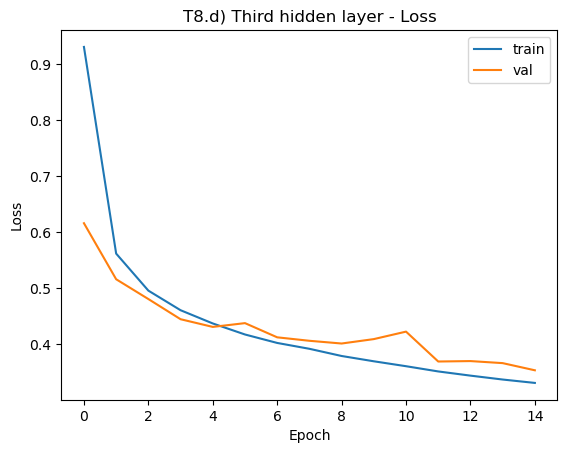

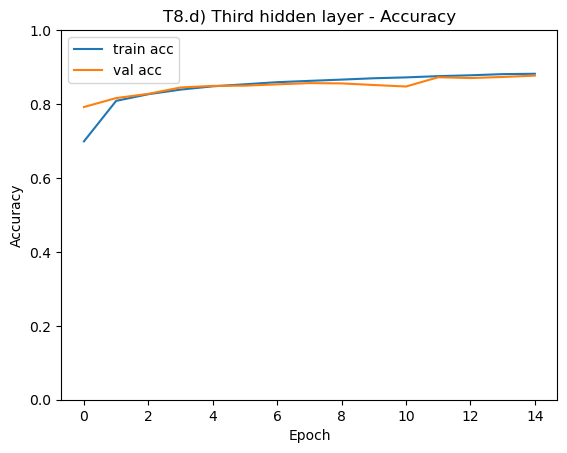

In [ ]:
# T8.d) - A third hidden layer

#We add a extra layer here consisting of 64 neurons
model3 = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),  #Extra layer
    Dense(10, activation='softmax')
])
model3.compile(
    #optimizer='adam',  # TODO: try 'adam'
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = "logs/mlp_extra_layer_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

history3 = model3.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)
plt.plot(history3.history['loss'], label='train')
plt.plot(history3.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('T8.d) Third hidden layer - Loss')
plt.show()

plt.figure()
plt.plot(history3.history['accuracy'], label='train acc')
plt.plot(history3.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.title('T8.d) Third hidden layer - Accuracy')
plt.show()

### T8.e) Experiment with different numbers of neurons

To further understand the effect of the neurons we try to increase the neurons to 512 -> 256 -> 128.

Compaed to the test from T8.d) this only resulted in a minimal improvement in accuracy and loss. See the code below

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7298 - loss: 0.8700 - val_accuracy: 0.7980 - val_loss: 0.5937
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8194 - loss: 0.5280 - val_accuracy: 0.8224 - val_loss: 0.4966
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8357 - loss: 0.4745 - val_accuracy: 0.8342 - val_loss: 0.4764
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8445 - loss: 0.4458 - val_accuracy: 0.8474 - val_loss: 0.4433
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8509 - loss: 0.4226 - val_accuracy: 0.8503 - val_loss: 0.4176
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8586 - loss: 0.4052 - val_accuracy: 0.8558 - val_loss: 0.4132
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8617 - loss: 0.3926 - val_accuracy: 0.8577 - val_loss: 0.3987
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8668 - loss: 0.3792 - val_accuracy: 0.

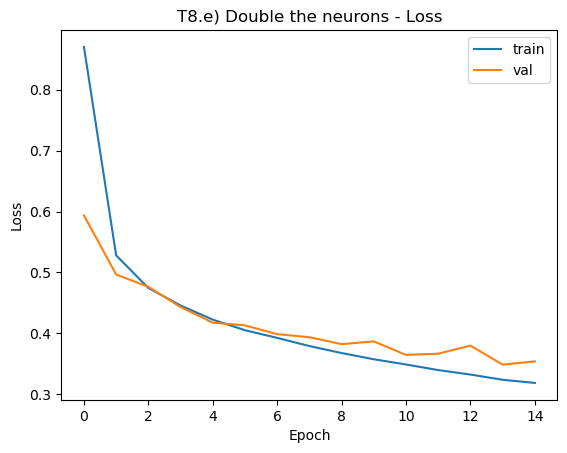

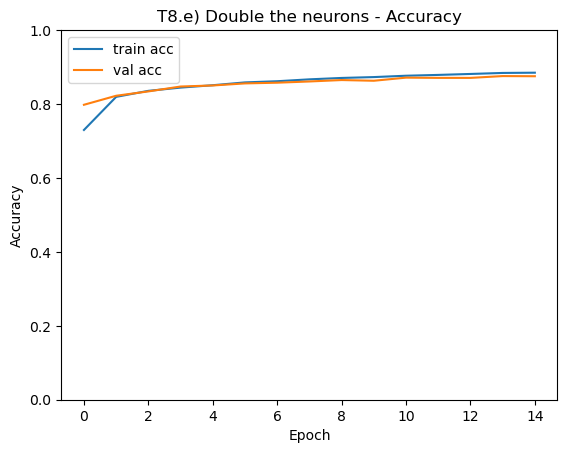

In [ ]:
# T8.e) - Different numbers of neurons

#We cnahge the numbers of neurons
model4 = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),  #Extra layer
    Dense(10, activation='softmax')
])
model4.compile(
    #optimizer='adam',  # TODO: try 'adam'
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = "logs/mlp_extra_neurons_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

history4 = model4.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)
plt.plot(history4.history['loss'], label='train')
plt.plot(history4.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('T8.e) Double the neurons - Loss')
plt.show()

plt.figure()
plt.plot(history4.history['accuracy'], label='train acc')
plt.plot(history4.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.title('T8.e) Double the neurons - Accuracy')
plt.show()

### T8.f) Try other activation functions (e.g. tanh, elu) - explain the functions

We try with both tanh and elu. Previously we used ReLu which sets negative values to 0 and maintains positive values.

The tanh function is the hyperbolic tangent, which maps the input to a value between -1 and 1.

The elu function is the exponential linear unit function which, like ReLu, keeps positive values but gives a smooth negative curve. This can be useful if differentiation is required.

For comparison the model with an extra hidden layer is run. The results can be seen below for the elu and tanh function but comparison is done in Tensorboard resulting in the following curves for accuracy.
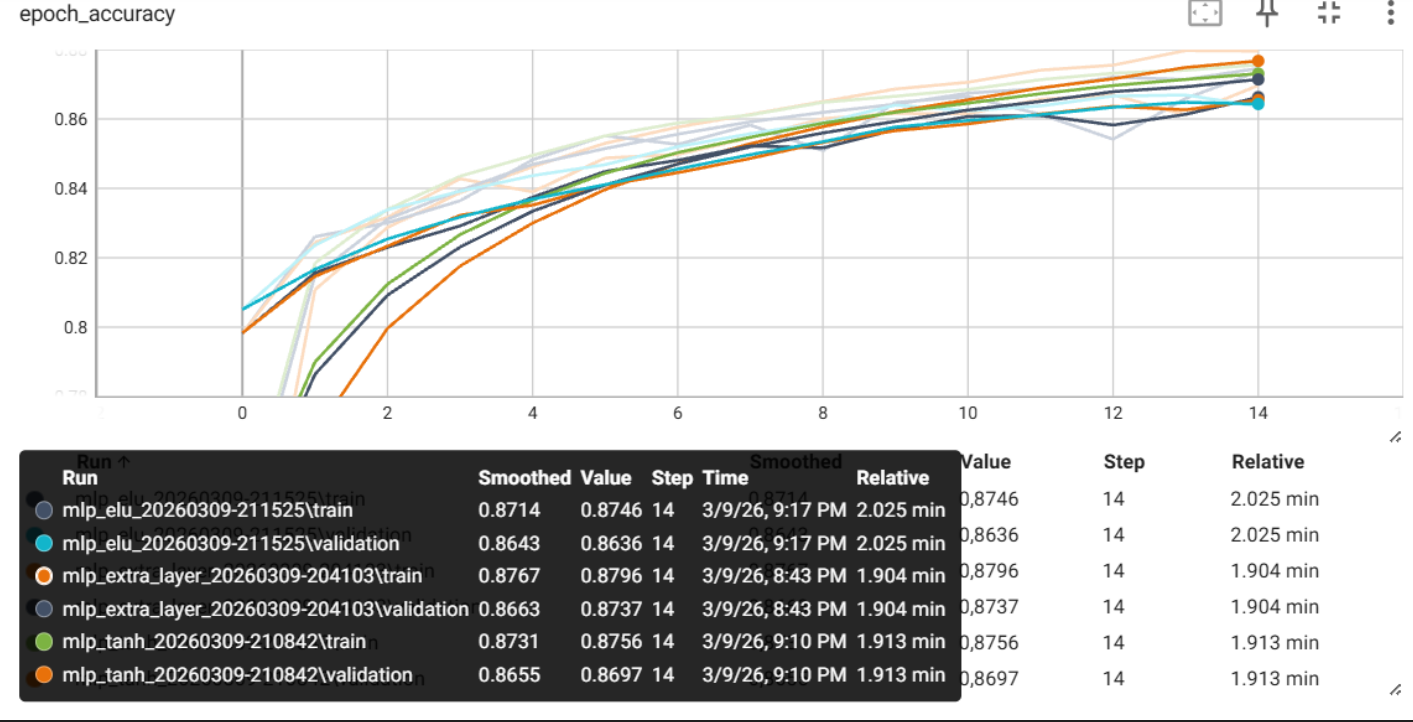

In [ ]:
# T8. f) Other activation functions

#We define a function to build the models
def build_model(activation):
    model = Sequential([
        tf.keras.Input(shape=(28, 28)),
        Flatten(),
        Dense(256, activation=activation),
        Dense(128, activation=activation),
        Dense(64, activation=activation),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7355 - loss: 0.8356 - val_accuracy: 0.7980 - val_loss: 0.5971
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8145 - loss: 0.5414 - val_accuracy: 0.8207 - val_loss: 0.5056
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8310 - loss: 0.4814 - val_accuracy: 0.8312 - val_loss: 0.4680
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8411 - loss: 0.4501 - val_accuracy: 0.8407 - val_loss: 0.4436
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8468 - loss: 0.4287 - val_accuracy: 0.8426 - val_loss: 0.4320
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8532 - loss: 0.4137 - val_accuracy: 0.8484 - val_loss: 0.4142
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8567 - loss: 0.4009 - val_accuracy: 0.8527 - val_loss: 0.4095
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8599 - loss: 0.3909 - val_accuracy: 0.

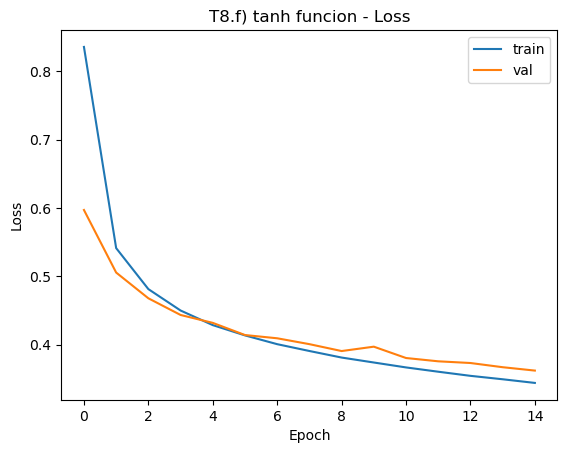

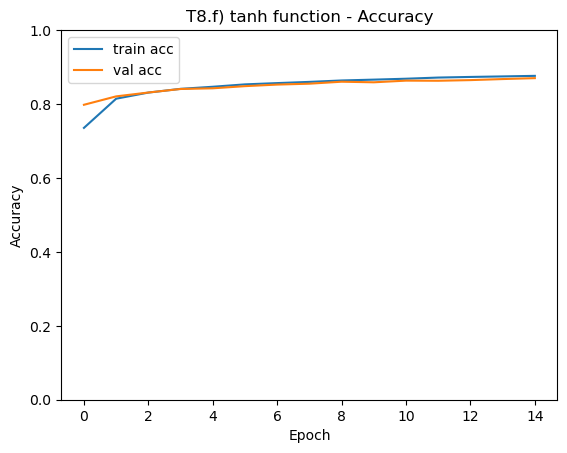

In [ ]:
#The tanh model
model_tanh = build_model('tanh')

log_dir = "logs/mlp_tanh_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

history_tanh = model_tanh.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=callbacks,
    batch_size=64
)
plt.plot(history_tanh.history['loss'], label='train')
plt.plot(history_tanh.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('T8.f) tanh funcion - Loss')
plt.show()

plt.figure()
plt.plot(history_tanh.history['accuracy'], label='train acc')
plt.plot(history_tanh.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.title('T8.f) tanh function - Accuracy')
plt.show()

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7376 - loss: 0.7828 - val_accuracy: 0.8032 - val_loss: 0.5614
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8179 - loss: 0.5227 - val_accuracy: 0.8201 - val_loss: 0.4979
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8325 - loss: 0.4762 - val_accuracy: 0.8282 - val_loss: 0.4735
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8415 - loss: 0.4508 - val_accuracy: 0.8351 - val_loss: 0.4589
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8457 - loss: 0.4349 - val_accuracy: 0.8399 - val_loss: 0.4420
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8509 - loss: 0.4200 - val_accuracy: 0.8481 - val_loss: 0.4238
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8561 - loss: 0.4080 - val_accuracy: 0.8500 - val_loss: 0.4257
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8590 - loss: 0.3988 - val_accuracy: 0.

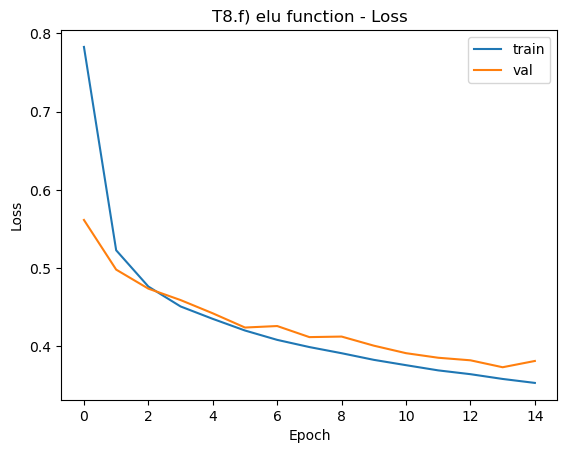

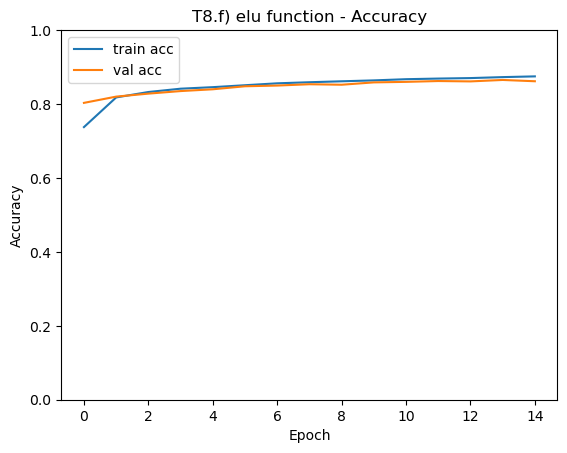

In [ ]:
#The elu model
model_elu = build_model('elu')

log_dir = "logs/mlp_elu_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

history_elu = model_elu.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)
plt.plot(history_elu.history['loss'], label='train')
plt.plot(history_elu.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('T8.f) elu function - Loss')
plt.show()

plt.figure()
plt.plot(history_elu.history['accuracy'], label='train acc')
plt.plot(history_elu.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.title('T8.f) elu function - Accuracy')
plt.show()

### T8.g) Add dropout layers and compare training results

Dropout means that we randomly turns of a certain amount of the neurons during training. In this case we choose to use a dropout rate of 0.3. The model is built below where we continue with the hidden layer version. The compariosn is done in TensorBoard and shown on the following picture. 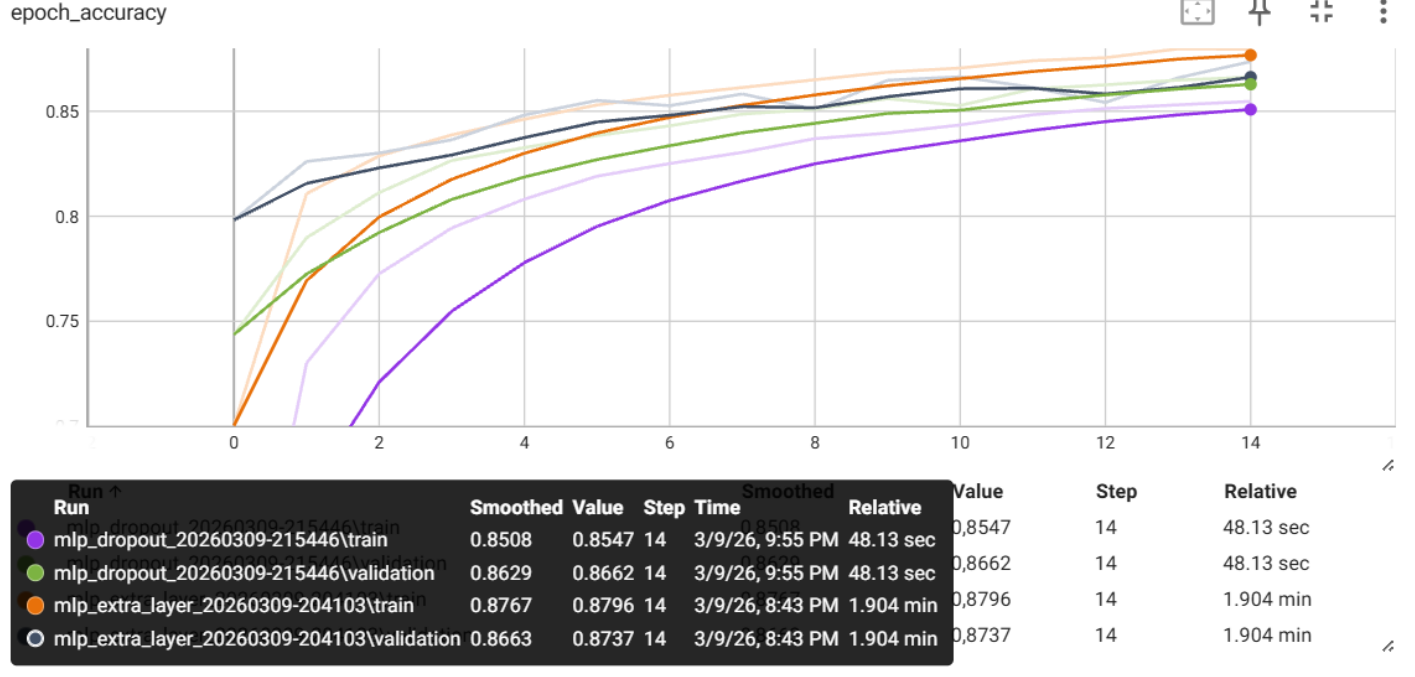 Where we can see that the training accuracy has dropped but the validation accuracy is almost the same and is actually higher than the training accuracy, which is the opposite compared to the standard model.


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5652 - loss: 1.2292 - val_accuracy: 0.7553 - val_loss: 0.6854
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7331 - loss: 0.7372 - val_accuracy: 0.7933 - val_loss: 0.5691
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7709 - loss: 0.6372 - val_accuracy: 0.8197 - val_loss: 0.5177
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7969 - loss: 0.5791 - val_accuracy: 0.8259 - val_loss: 0.4889
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8088 - loss: 0.5437 - val_accuracy: 0.8368 - val_loss: 0.4569
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8201 - loss: 0.5120 - val_accuracy: 0.8397 - val_loss: 0.4435
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8273 - loss: 0.4892 - val_accuracy: 0.8457 - val_loss: 0.4296
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8350 - loss: 0.4699 - val_accuracy: 0.

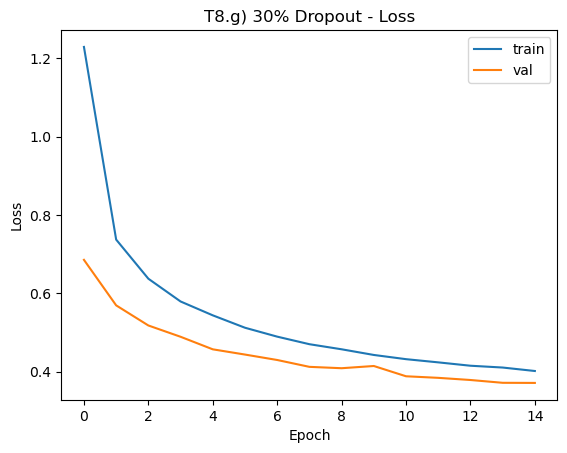

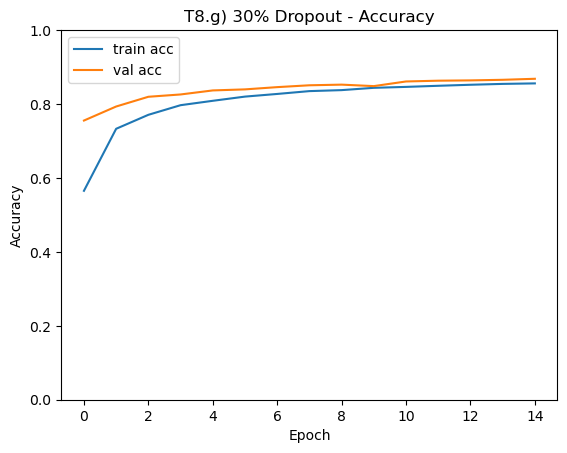

In [ ]:
def build_model_with_dropout(activation='relu', dropout_rate=0.3):
    model = Sequential([
        tf.keras.Input(shape=(28, 28)),
        Flatten(),
        Dense(256, activation=activation),
        Dropout(dropout_rate),
        Dense(128, activation=activation),
        Dropout(dropout_rate),
        Dense(64, activation=activation),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_dropout = build_model_with_dropout(activation='relu', dropout_rate=0.3)

log_dir = "logs/mlp_dropout_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)
plt.plot(history_dropout.history['loss'], label='train')
plt.plot(history_dropout.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('T8.g) 30% Dropout - Loss')
plt.show()

plt.figure()
plt.plot(history_dropout.history['accuracy'], label='train acc')
plt.plot(history_dropout.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0, 1)
plt.title('T8.g) 30% Dropout - Accuracy')
plt.show()

### T8.h) Evaluate the model on the test dataset

We then have to evaluate the model on the test dataset, which is done simply with the evaluate command.

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test loss for standard model:", test_loss)
print("Test accuracy for standard model:", test_acc)

test_loss_epoch, test_acc_epoch = model2.evaluate(X_test, y_test)
print("Test loss for 70 epochs:", test_loss_epoch)
print("Test accuracy for 70 epochs:", test_acc_epoch)

test_loss_ReLu, test_acc_ReLu = model3.evaluate(X_test, y_test)
print("Test loss for ReLu:", test_loss_ReLu)
print("Test accuracy for ReLu:", test_acc_ReLu)

test_loss_Double, test_acc_Double = model4.evaluate(X_test, y_test)
print("Test loss for double neurons:", test_loss_Double)
print("Test accuracy for double neurons:", test_acc_Double)

test_loss_tanh, test_acc_tanh = model_tanh.evaluate(X_test, y_test)
print("Test loss for tanh:", test_loss_tanh)
print("Test accuracy for tanh:", test_acc_tanh)

test_loss_elu, test_acc_elu = model_elu.evaluate(X_test, y_test)
print("Test loss for elu:", test_loss_elu)
print("Test accuracy for elu:", test_acc_elu)

test_loss_dropout, test_acc_dropout = model_dropout.evaluate(X_test, y_test)
print("Test loss for dropout:", test_loss_dropout)
print("Test accuracy for dropout:", test_acc_dropout)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8576 - loss: 0.3995
Test loss for standard model: 0.3994550406932831
Test accuracy for standard model: 0.8575999736785889
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8789 - loss: 0.3406
Test loss for 70 epochs: 0.3405906558036804
Test accuracy for 70 epochs: 0.8788999915122986
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8669 - loss: 0.3797
Test loss for ReLu: 0.3797443211078644
Test accuracy for ReLu: 0.8669000267982483
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8671 - loss: 0.3717
Test loss for double neurons: 0.37173712253570557
Test accuracy for double neurons: 0.8671000003814697
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8592 - loss: 0.3919
Test loss for tanh: 0.39188897609710693
Test accuracy for tanh: 0.8592000007629395
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8587 - loss: 0.4001
Test loss for elu: 0.4000735580921173
Test accuracy for elu: 0.8586999773979187
313/313 

### T8.i) Save and reload the trained model

The models can be saved and reloaded as shown below. It can then be used like any other model.

In [ ]:
#Saving the model
model_dropout.save("fashion_mnist_dropout.keras")

#Loading the model
loaded_model = tf.keras.models.load_model("fashion_mnist_dropout.keras")

## Questions on model training

We have to answer the following questions.

### Q8.a) Explain the purpose of dropout layers?

Dropout randomly turns off a certain fraction of neurons during the training of the model which helps to reduce overfitting since it prevents the model from fitting too much to certain data by constantly changing the considered data. It is therefore forced to learn more robust patterns which better generalizes to useen data. 

### Q8.b) Explain and compare overfitting vs. underfitting

Overfitting and underfitting are both problems which can occur during training. Underfitting means the model is too simple and has not learned enough of the pattern of the data. The model typically performs quite badly even on the training data. Overfitting, on the other hand, results from the model fitting to specifically to the data, often including noise. this typically results in high training accuracy but a much lower validation accuracy.

### Q8.b) What impact does patience have in early stopping?

Patience controls how many epochs the model will keep training after the validation loss or the chosen parameter has stopped improving. In this case it is 5 epochs.

### Q8.c) What happens with a SGD learning rate of smaller values such as 0.001?

With smaller SGD learning rates, the training becomes slower as can be clearly seen by comparing the plots for the original model with a learning rate of 0.01 and the model from T8.b) with a learning rate of 0.001.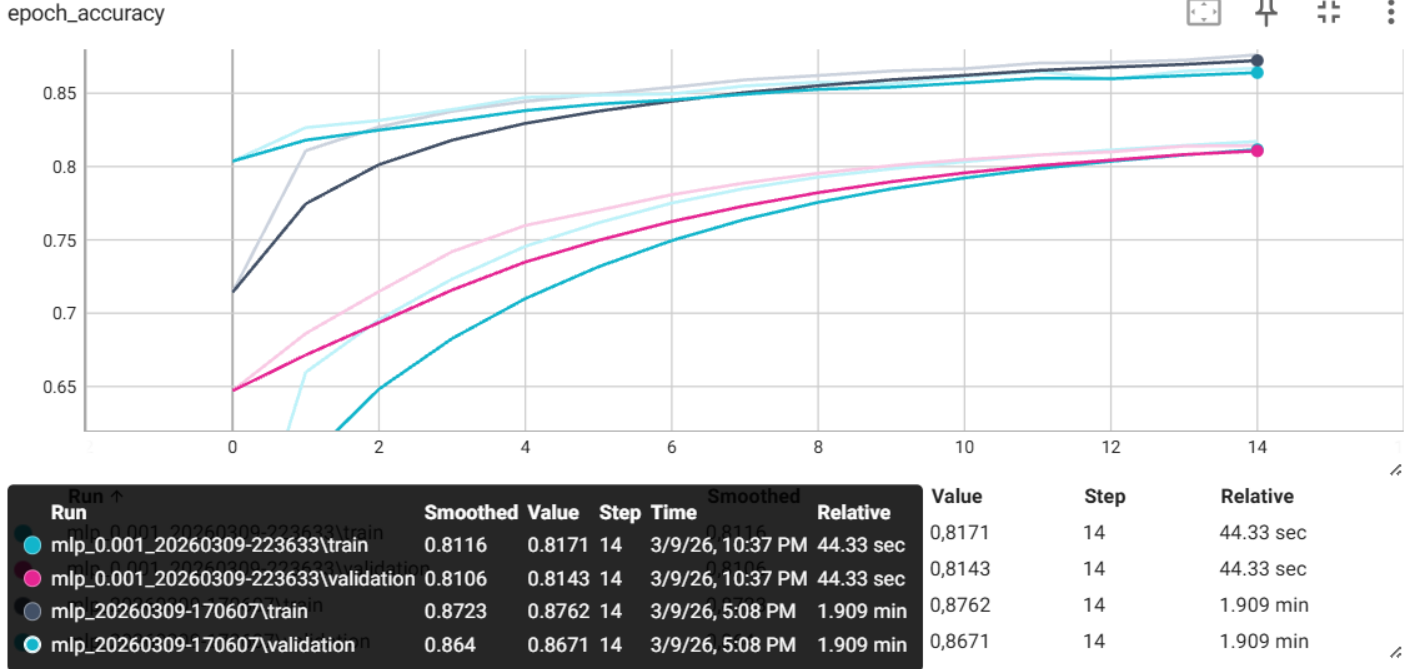 Where it can be seen that the smaller learning rate results in a significantly slower learning process, meaning it will take many more epochs to achieve the same results. It can however also be more stable and the curves for the lower learning rate is generally more stable.


### Q8.d) Compare Adam optimizer with SGD

Comparison of the Adam optimizer with SGD can be done in Tensorboard by plotting the data for SGD and Adam models, both with a learning rate of 0.001.
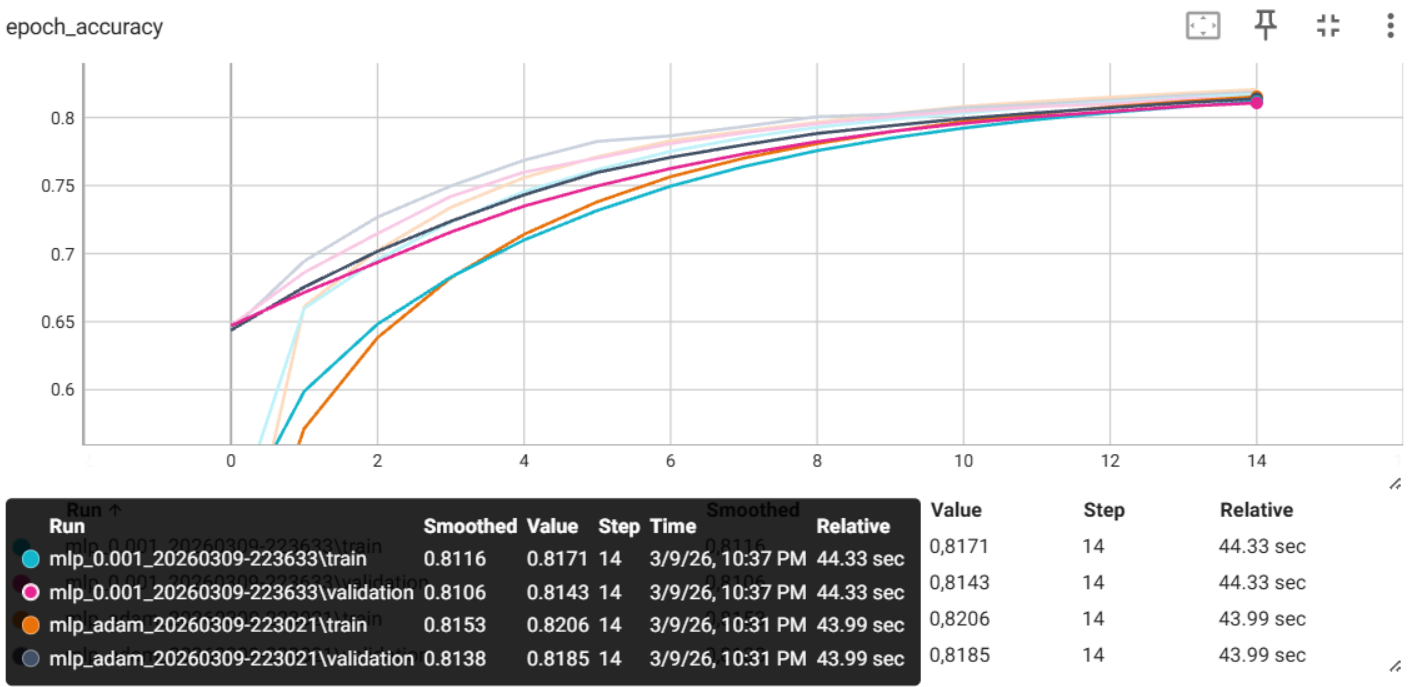 In this case, there is not a big difference but it can still be seen that the Adams models gets a slighly better results and reaches the validation line slightly faster.



## Additional questions for reflection

### Q8.e) Show how to find and calculate the 200.960 parameters in the first layer.

The number of parameters is calculated based input image being 28 by 28, meaning there is 28x28=784 inputs. There is then 256 neurons, which gives 784x256=200704 parameters which summed with the 256 bias inputs gives 200960.

The parameters themselves are computed during the training process by starting with a forward propogation for a prediction. The loss or error is then calculated and backward propogation is then used to find the gradient of the weight to determine which should change. The weights are then calculated as:

$w_1 \rightarrow \mathbf{w}_1 - \delta \frac{\partial L}{\partial w_1}$

The gradients themselves ae calculated based on the chain rule.

$\frac{\partial L}{\partial \hat{w}_1}
=
\frac{\partial L}{\partial F}
\frac{\partial F}{\partial z}
\frac{\partial z}{\partial \hat{w}_1}$

### Q8.f) Which optimizer performed best and why?

The two optimizer performed very similarly in this case but the Adam can still be considered to have performed slighly better based on the previously shown plot from TensorBoard where is has a slighly better end result. The training and validation curves are generally also much closer with adams than with SGD. This is because SGD only takes into account the current gradient while Adam also adjust the weights based on past gradients.

### Q8.g) How did the number of layers affect performance?

To illustrate the effect of the number of layers, the performance of the standard model can be compared to the one with an extra hidden layer in TensorBoard. 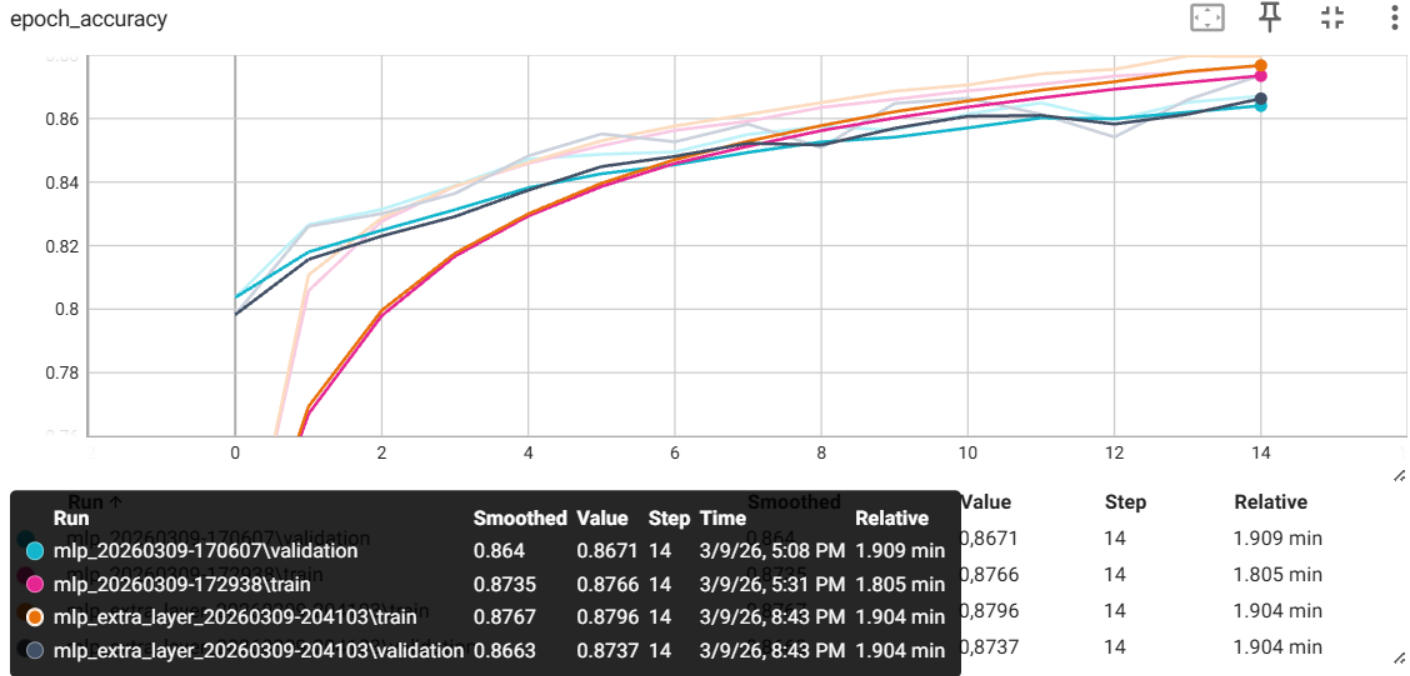 It can then be seen that the extra layers generally improved the performance of the model since both the test and validation accuracy was slighly better.

### Q8.h) Did EarlyStopping help prevent overfitting? (try with more training epochs)

To check whether Earlystopping helped to prevent overfitting, the code from T8.b) was rerun with 70 epoch which resulted in the following plot.
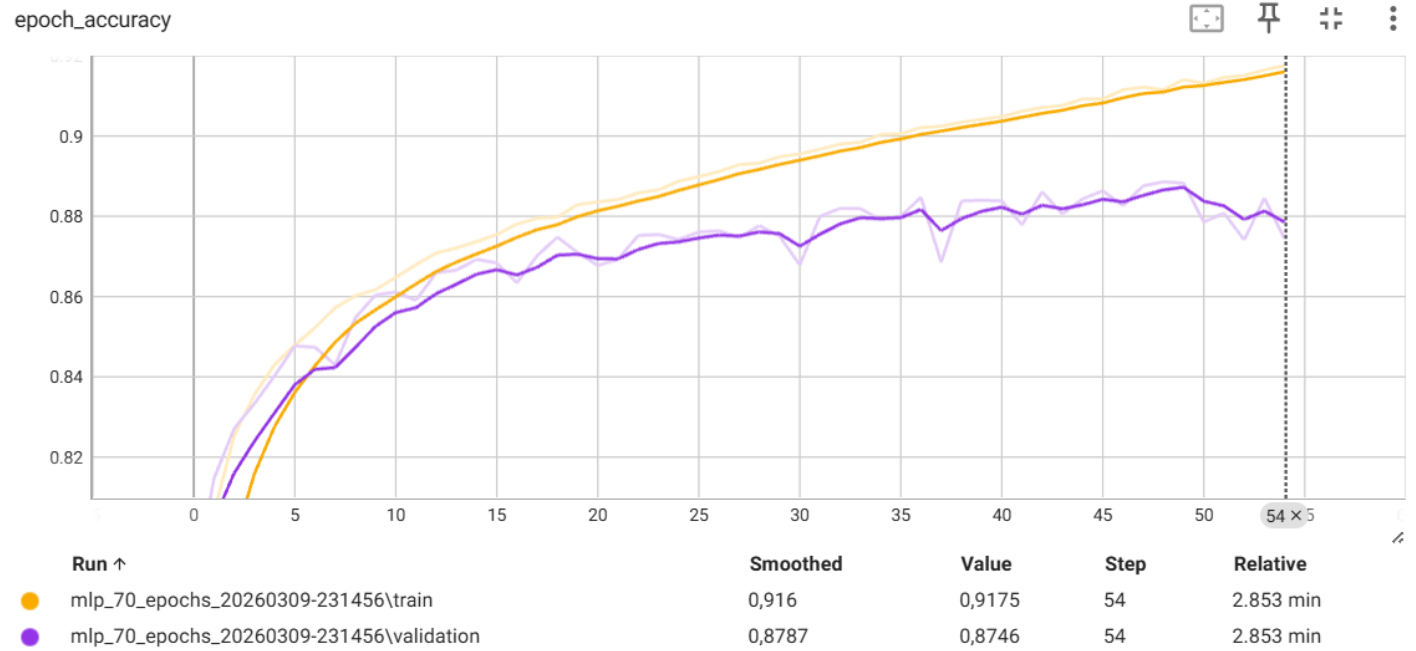 From which we can see that it did not prevent overfitting since we can see the exact characteristics of overfitting where the training accuracy keeps increasing and the validation accuracy is noticeably lower and has stopped increasing.

### Q8.i) What hyperparameters (neurons, layers, dropout..) had the biggest impact?

Based on the evaluated results of T8.h), layers had the biggest impact on the performance and then the numbers of neurons.   